# 🏠 Ames Housing Dataset — معرفی و آشنایی با داده‌ها

**درس:** دیداری‌سازی داده‌ها  
**دانشجو:** سارا دهقانی

**دیتاست:** Ames Housing Dataset

---

## 📌 درباره دیتاست
این دیتاست توسط **Dean De Cock** در سال ۲۰۱۱ منتشر شده و شامل اطلاعات فروش واقعی خانه‌های شهر **Ames، Iowa** آمریکا بین سال‌های ۲۰۰۶ تا ۲۰۱۰ است.  
هدف اصلی: **پیش‌بینی قیمت فروش خانه (SalePrice)** بر اساس ۸۰ ویژگی مختلف.

## 🎯 هدف پروژه

تحلیل عوامل مؤثر بر قیمت مسکن در شهر Ames و مصورسازی روابط بین
ویژگی‌های خانه با قیمت فروش، با هدف پاسخ به سؤالات زیر:
- کدام ویژگی‌ها بیشترین تأثیر را بر قیمت دارند؟
- آیا محله زندگی روی قیمت تأثیر دارد؟
- خانه‌های جدیدتر لزوماً گران‌ترند؟
- آیا فصل فروش روی قیمت اثر می‌گذارد؟

In [2]:
# 1. بارگذاری کتابخانه‌ها و داده‌ها
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import subprocess
subprocess.run(['pip', 'install', 'arabic-reshaper', 'python-bidi'], capture_output=True)

import arabic_reshaper
from bidi.algorithm import get_display

def fa(text):
    """تبدیل متن فارسی به فرمت قابل نمایش در matplotlib"""
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)
    
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
ORANGE = '#D85A30'
PURPLE = '#7F77DD'
AMBER  = '#BA7517'
PALETTE = [BLUE, GREEN, ORANGE, PURPLE, AMBER]

# بارگذاری دیتاست
df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
print(f'✅ دیتاست بارگذاری شد: {df.shape[0]} خانه، {df.shape[1]} ستون')


✅ دیتاست بارگذاری شد: 1460 خانه، 81 ستون


In [3]:
df_raw = df.copy()
print('✅ نسخه اصلی ذخیره شد:', df_raw.shape)

✅ نسخه اصلی ذخیره شد: (1460, 81)


In [4]:
#2. نگاه اول به داده‌ها
# نمایش ۵ ردیف اول
df.head()
# ابعاد و نوع داده‌ها
print('=' * 50)
print(f'تعداد نمونه‌ها (خانه):  {df.shape[0]}')
print(f'تعداد ویژگی‌ها:          {df.shape[1] - 1}  (+ 1 ستون هدف)')
print('=' * 50)
num_cols = df.select_dtypes(include='number').columns.drop(['Id','SalePrice']).tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'ویژگی‌های عددی:   {len(num_cols)}')
print(f'ویژگی‌های متنی:    {len(cat_cols)}')
print(f'ستون هدف:         SalePrice')
# اطلاعات کلی
df.info()

تعداد نمونه‌ها (خانه):  1460
تعداد ویژگی‌ها:          80  (+ 1 ستون هدف)
ویژگی‌های عددی:   36
ویژگی‌های متنی:    43
ستون هدف:         SalePrice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 

In [5]:
# 3. آمار توصیفی ستون هدف (SalePrice)
sp = df['SalePrice']
print('آمار توصیفی SalePrice')
print('=' * 40)
print(f'کمترین قیمت:      ${sp.min():>10,.0f}')
print(f'چارک اول (Q1):    ${sp.quantile(0.25):>10,.0f}')
print(f'میانه:            ${sp.median():>10,.0f}')
print(f'میانگین:          ${sp.mean():>10,.0f}')
print(f'چارک سوم (Q3):    ${sp.quantile(0.75):>10,.0f}')
print(f'بیشترین قیمت:     ${sp.max():>10,.0f}')
print(f'انحراف معیار:     ${sp.std():>10,.0f}')
print(f'چولگی (Skewness): {sp.skew():>10.2f}  ← توزیع راست‌کج')

آمار توصیفی SalePrice
کمترین قیمت:      $    34,900
چارک اول (Q1):    $   129,975
میانه:            $   163,000
میانگین:          $   180,921
چارک سوم (Q3):    $   214,000
بیشترین قیمت:     $   755,000
انحراف معیار:     $    79,443
چولگی (Skewness):       1.88  ← توزیع راست‌کج


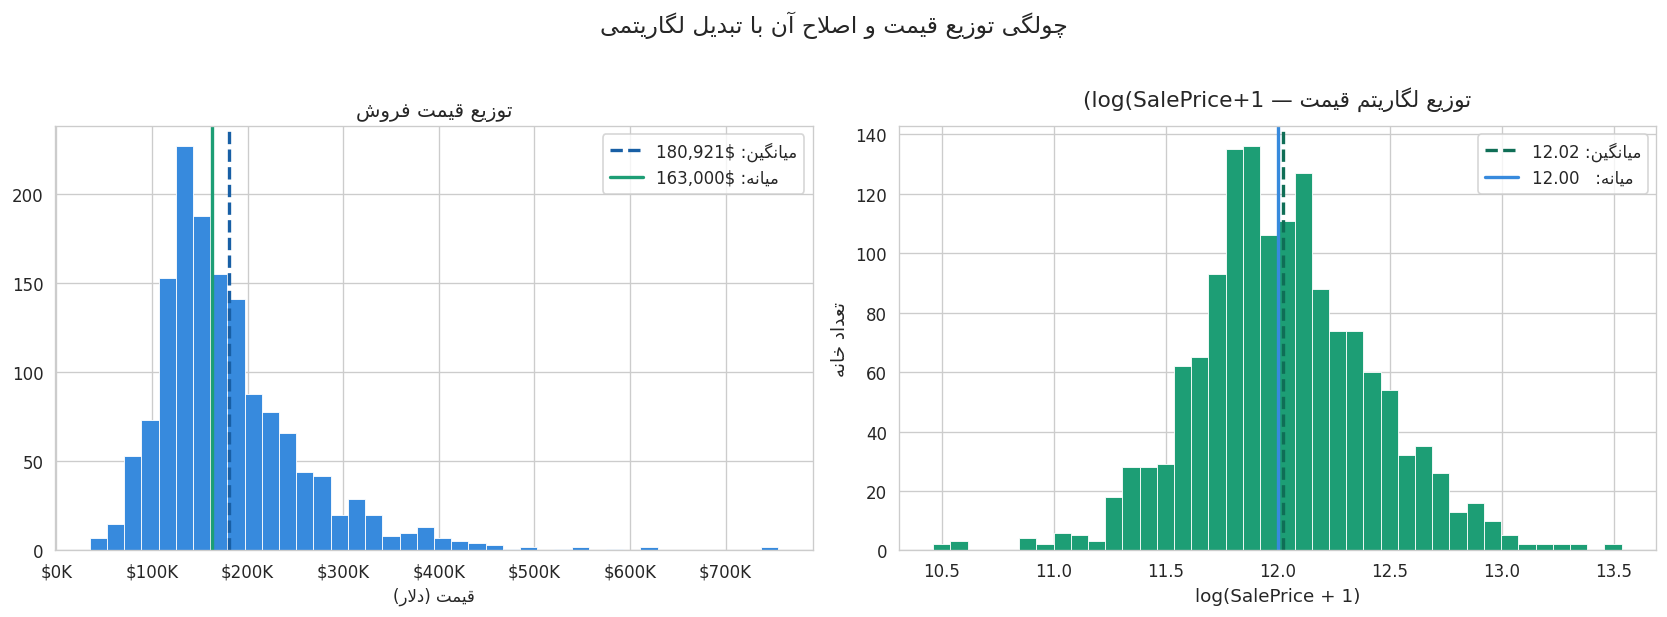

چولگی اصلی: 1.88  →  بعد از log: 0.12


In [6]:
# 4. توزیع قیمت فروش (هیستوگرام)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- هیستوگرام قیمت اصلی ---
ax = axes[0]
ax.hist(df['SalePrice'], bins=40, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(df['SalePrice'].mean(),
           color='#185FA5', linewidth=2, linestyle='--',
           label=fa(f"میانگین: ${df['SalePrice'].mean():,.0f}"))

ax.axvline(df['SalePrice'].median(),
           color=GREEN, linewidth=2, linestyle='-',
           label=fa(f"میانه: ${df['SalePrice'].median():,.0f}"))
ax.set_title(fa('توزیع قیمت فروش'))
ax.set_xlabel(fa('قیمت (دلار)'))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10)

# --- توزیع لگاریتمی ---
ax2 = axes[1]
log_price = np.log1p(df['SalePrice'])
ax2.hist(log_price, bins=40, color=GREEN, edgecolor='white', linewidth=0.5)
ax2.axvline(log_price.mean(),   
            color='#0F6E56', linewidth=2, linestyle='--', 
            label=fa(f'میانگین: {log_price.mean():.2f}'))
ax2.axvline(log_price.median(), 
            color=BLUE,      linewidth=2, linestyle='-',  
            label=fa(f'میانه:   {log_price.median():.2f}'))
ax2.set_title(fa('توزیع لگاریتم قیمت — log(SalePrice+1)'), fontsize=13, pad=12)
ax2.set_xlabel('log(SalePrice + 1)', fontsize=11)
ax2.set_ylabel(fa('تعداد خانه'), fontsize=11)
ax2.legend(fontsize=10)

plt.suptitle(fa('چولگی توزیع قیمت و اصلاح آن با تبدیل لگاریتمی'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f'چولگی اصلی: {df["SalePrice"].skew():.2f}  →  بعد از log: {log_price.skew():.2f}')

تعداد ستون‌های دارای مقدار گمشده: 19

              تعداد  درصد
PoolQC         1453  99.5
MiscFeature    1406  96.3
Alley          1369  93.8
Fence          1179  80.8
MasVnrType      872  59.7
FireplaceQu     690  47.3
LotFrontage     259  17.7
GarageType       81   5.5
GarageYrBlt      81   5.5
GarageFinish     81   5.5
GarageQual       81   5.5
GarageCond       81   5.5
BsmtExposure     38   2.6
BsmtFinType2     38   2.6
BsmtQual         37   2.5
BsmtCond         37   2.5
BsmtFinType1     37   2.5
MasVnrArea        8   0.5
Electrical        1   0.1


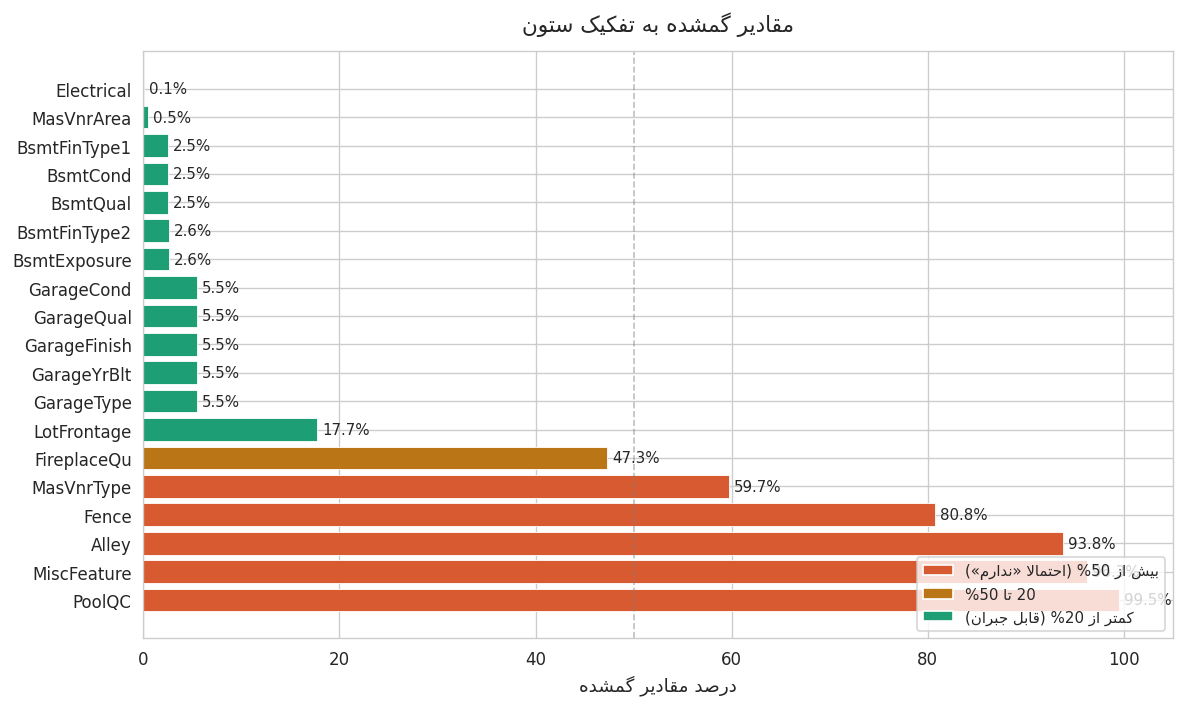

In [7]:
# 5. بررسی مقادیر گمشده (Missing Values)
# مقادیر گمشده در این دیتاست اکثراً به معنای «ندارم» هستند، نه خطای داده.
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'تعداد': missing, 'درصد': missing_pct})
print(f'تعداد ستون‌های دارای مقدار گمشده: {len(missing_df)}')
print()
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))

colors = [ORANGE if p > 50 else AMBER if p > 20 else GREEN for p in missing_pct.values]
bars = ax.barh(missing_df.index, missing_df['درصد'], color=colors, edgecolor='white', linewidth=0.5)

for bar, pct in zip(bars, missing_df['درصد']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50%')
ax.set_xlabel(fa('درصد مقادیر گمشده'), fontsize=11)
ax.set_title(fa('مقادیر گمشده به تفکیک ستون'), fontsize=13, pad=12)
ax.set_xlim(0, 105)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ORANGE, 
          label=fa('بیش از 50% (احتمالاً «ندارم»)')),
    Patch(facecolor=AMBER,  
          label=fa('20 تا 50%')),
    Patch(facecolor=GREEN,  
          label=fa('کمتر از 20% (قابل جبران)'))
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

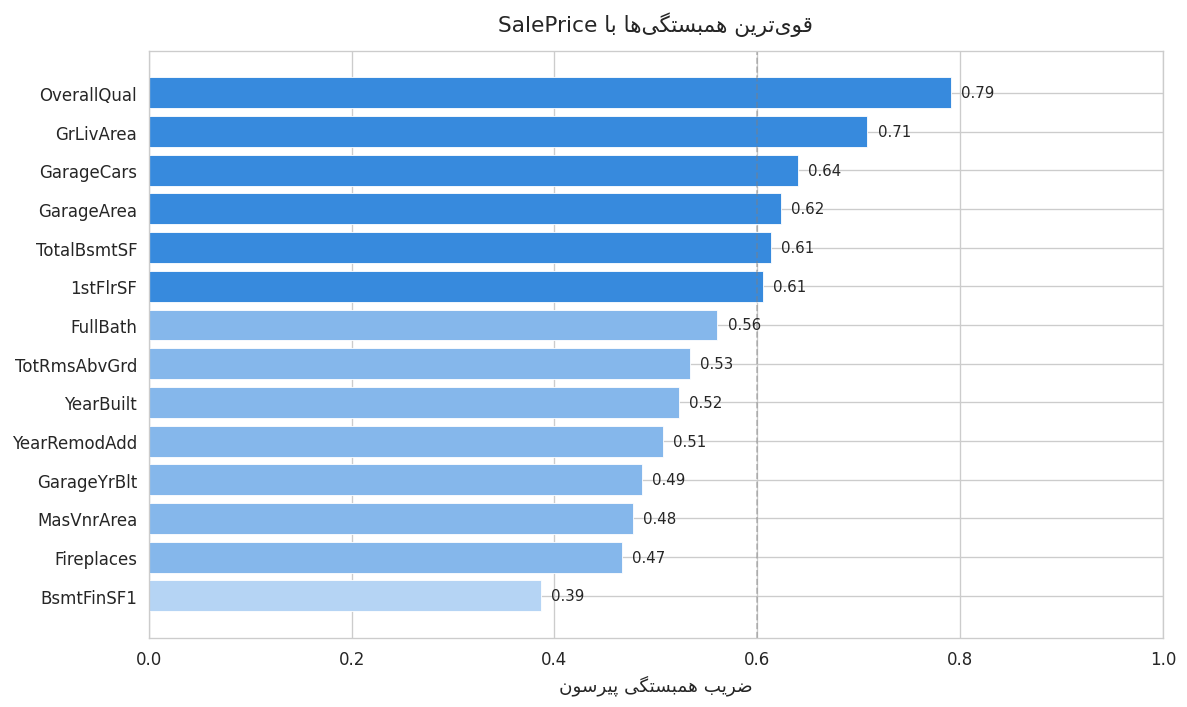

قوی‌ترین همبستگی: OverallQual با 0.79
ضعیف‌ترین همبستگی در top14: BsmtFinSF1 با 0.39


In [8]:
# 6. همبستگی ویژگی‌های عددی با SalePrice
corr = df[num_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
corr_sorted = corr.abs().sort_values(ascending=False).head(14)
corr_vals   = corr[corr_sorted.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [BLUE if v > 0.6 else '#85B7EB' if v > 0.4 else '#B5D4F4' for v in corr_vals.values]
ax.barh(corr_sorted.index[::-1], corr_vals.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

for i, (idx, val) in enumerate(zip(corr_sorted.index[::-1], corr_vals.values[::-1])):
    ax.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

ax.set_xlim(0, 1)
ax.set_xlabel(fa('ضریب همبستگی پیرسون'), fontsize=11)
ax.set_title(fa('قوی‌ترین همبستگی‌ها با SalePrice'), fontsize=13, pad=12)
ax.axvline(0.6, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()
print(f'قوی‌ترین همبستگی: OverallQual با {corr_vals.max():.2f}')
print(f'ضعیف‌ترین همبستگی در top14: {corr_sorted.index[-1]} با {corr_sorted.iloc[-1]:.2f}')

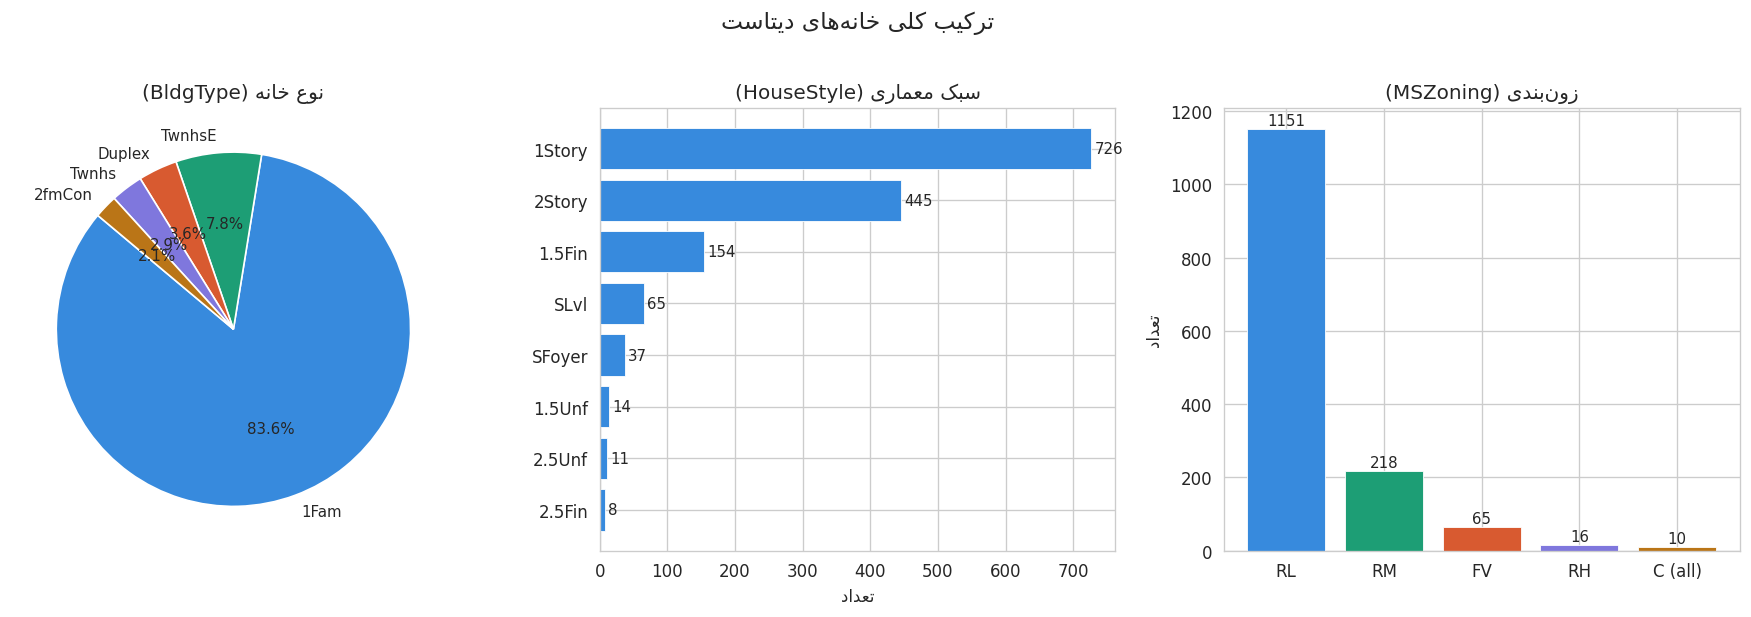

رایج‌ترین نوع خانه: 1Fam با 1220 خانه (84%)
رایج‌ترین سبک معماری: 1Story با 726 خانه


In [9]:
# 7. توزیع نوع خانه و سبک معماری
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- نوع خانه ---
bldg_counts = df['BldgType'].value_counts()
axes[0].pie(bldg_counts.values, labels=bldg_counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=140, textprops={'fontsize': 9})
axes[0].set_title(fa('نوع خانه (BldgType)'), fontsize=12)

# --- سبک معماری ---
style_counts = df['HouseStyle'].value_counts()
axes[1].barh(style_counts.index[::-1], style_counts.values[::-1],
             color=BLUE, edgecolor='white', linewidth=0.5)
for i, v in enumerate(style_counts.values[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)
axes[1].set_title(fa('سبک معماری (HouseStyle)'), fontsize=12)
axes[1].set_xlabel(fa('تعداد'))

# --- زون‌بندی ---
zone_counts = df['MSZoning'].value_counts()
axes[2].bar(zone_counts.index, zone_counts.values,
            color=PALETTE, edgecolor='white', linewidth=0.5)
for i, v in enumerate(zone_counts.values):
    axes[2].text(i, v + 10, str(v), ha='center', fontsize=9)
axes[2].set_title(fa('زون‌بندی (MSZoning)'), fontsize=12)
axes[2].set_ylabel(fa('تعداد'))

plt.suptitle(fa('ترکیب کلی خانه‌های دیتاست'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f'رایج‌ترین نوع خانه: {bldg_counts.index[0]} با {bldg_counts.iloc[0]} خانه ({bldg_counts.iloc[0]/len(df)*100:.0f}%)')
print(f'رایج‌ترین سبک معماری: {style_counts.index[0]} با {style_counts.iloc[0]} خانه')

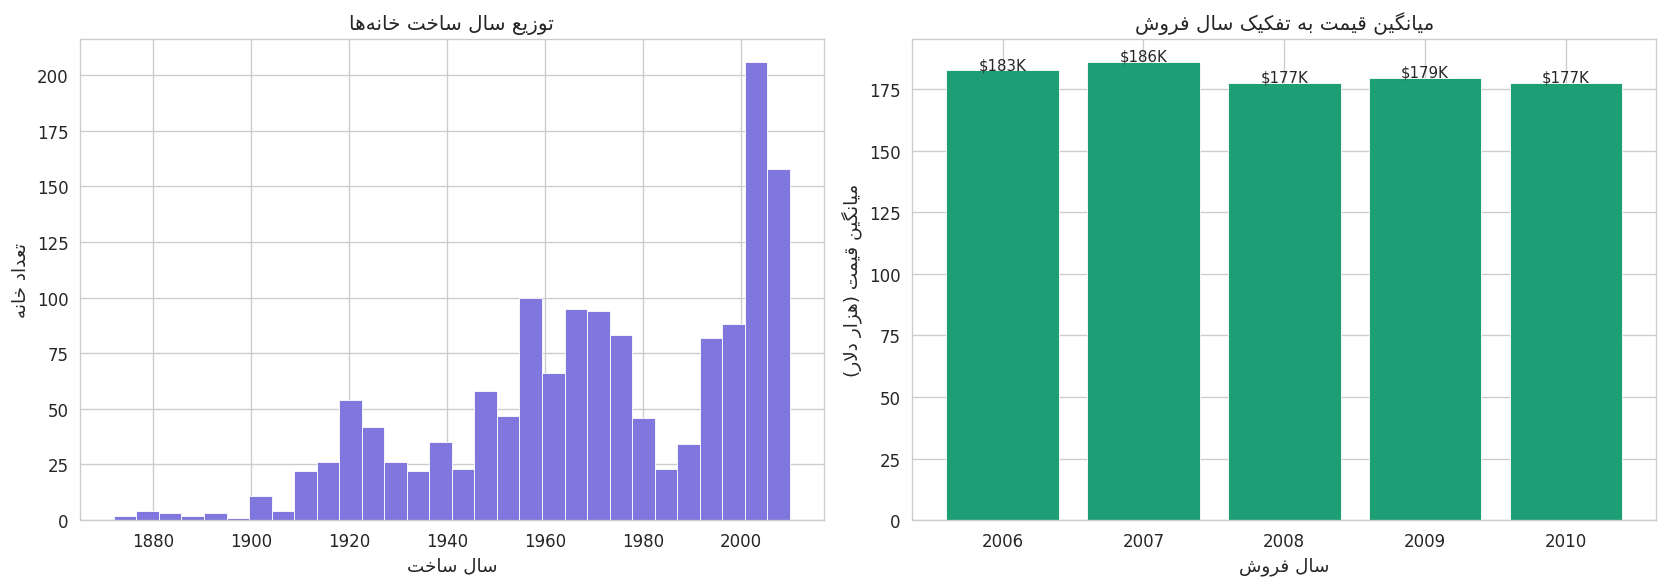

بیشترین ساخت‌وساز در دهه: 2000s
بهترین سال از نظر میانگین قیمت: 2007 با $186,063


In [10]:
# 8. توزیع زمانی — سال ساخت و فروش
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# سال ساخت
axes[0].hist(df['YearBuilt'], bins=30, color=PURPLE, edgecolor='white', linewidth=0.5)
axes[0].set_title(fa('توزیع سال ساخت خانه‌ها'), fontsize=12)
axes[0].set_xlabel(fa('سال ساخت'), fontsize=11)
axes[0].set_ylabel(fa('تعداد خانه'), fontsize=11)

# میانگین قیمت به تفکیک سال فروش
yr_price = df.groupby('YrSold')['SalePrice'].mean()
axes[1].bar(yr_price.index.astype(str), yr_price.values / 1000,
            color=GREEN, edgecolor='white', linewidth=0.5)
for i, v in enumerate(yr_price.values):
    axes[1].text(i, v/1000 + 0.5, f'${v/1000:.0f}K', ha='center', fontsize=9)
axes[1].set_title(fa('میانگین قیمت به تفکیک سال فروش'), fontsize=12)
axes[1].set_xlabel(fa('سال فروش'), fontsize=11)
axes[1].set_ylabel(fa('میانگین قیمت (هزار دلار)'), fontsize=11)

plt.tight_layout()
plt.show()
print(f'بیشترین ساخت‌وساز در دهه: {(df["YearBuilt"]//10*10).value_counts().idxmax()}s')
print(f'بهترین سال از نظر میانگین قیمت: {yr_price.idxmax()} با ${yr_price.max():,.0f}')

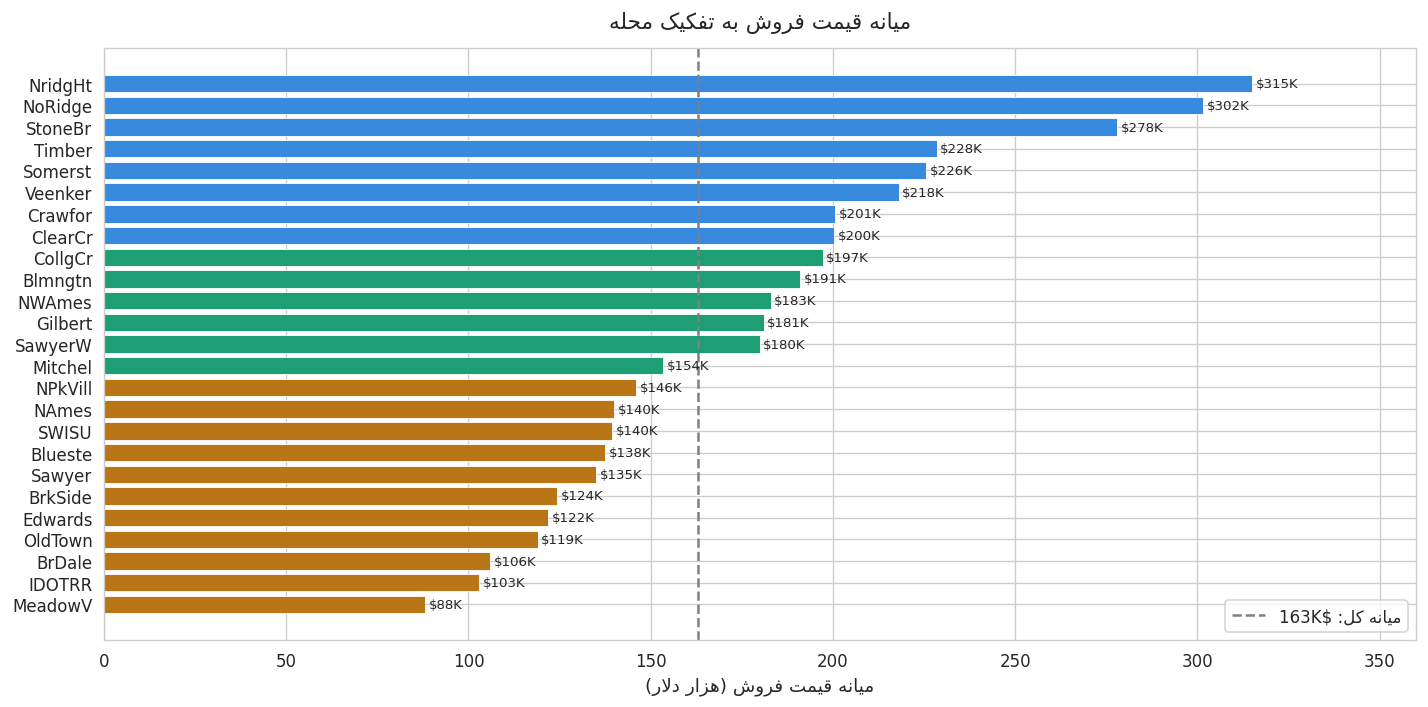

گران‌ترین محله: NridgHt با میانه $315,000
ارزان‌ترین محله: MeadowV با میانه $88,000
اختلاف قیمت بین گران‌ترین و ارزان‌ترین محله: 3.6 برابر


In [11]:
# 9. محله‌های پرتکرار و قیمت میانه آن‌ها
neigh_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_n = [BLUE if v > 200000 else GREEN if v > 150000 else AMBER for v in neigh_price.values]
ax.barh(neigh_price.index[::-1], neigh_price.values[::-1] / 1000, color=colors_n[::-1],
        edgecolor='white', linewidth=0.5)

for i, v in enumerate(neigh_price.values[::-1]):
    ax.text(v/1000 + 1, i, f'${v/1000:.0f}K', va='center', fontsize=8)

ax.axvline(df['SalePrice'].median()/1000, 
           color='gray', linestyle='--',
           linewidth=1.5, label=fa(f'میانه کل: ${df["SalePrice"].median()/1000:.0f}K'))
ax.set_xlabel(fa('میانه قیمت فروش (هزار دلار)'), fontsize=11)
ax.set_title(fa('میانه قیمت فروش به تفکیک محله'), fontsize=13, pad=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 360)
plt.tight_layout()
plt.show()
print(f'گران‌ترین محله: {neigh_price.index[0]} با میانه ${neigh_price.iloc[0]:,.0f}')
print(f'ارزان‌ترین محله: {neigh_price.index[-1]} با میانه ${neigh_price.iloc[-1]:,.0f}')
print(f'اختلاف قیمت بین گران‌ترین و ارزان‌ترین محله: {neigh_price.iloc[0]/neigh_price.iloc[-1]:.1f} برابر')

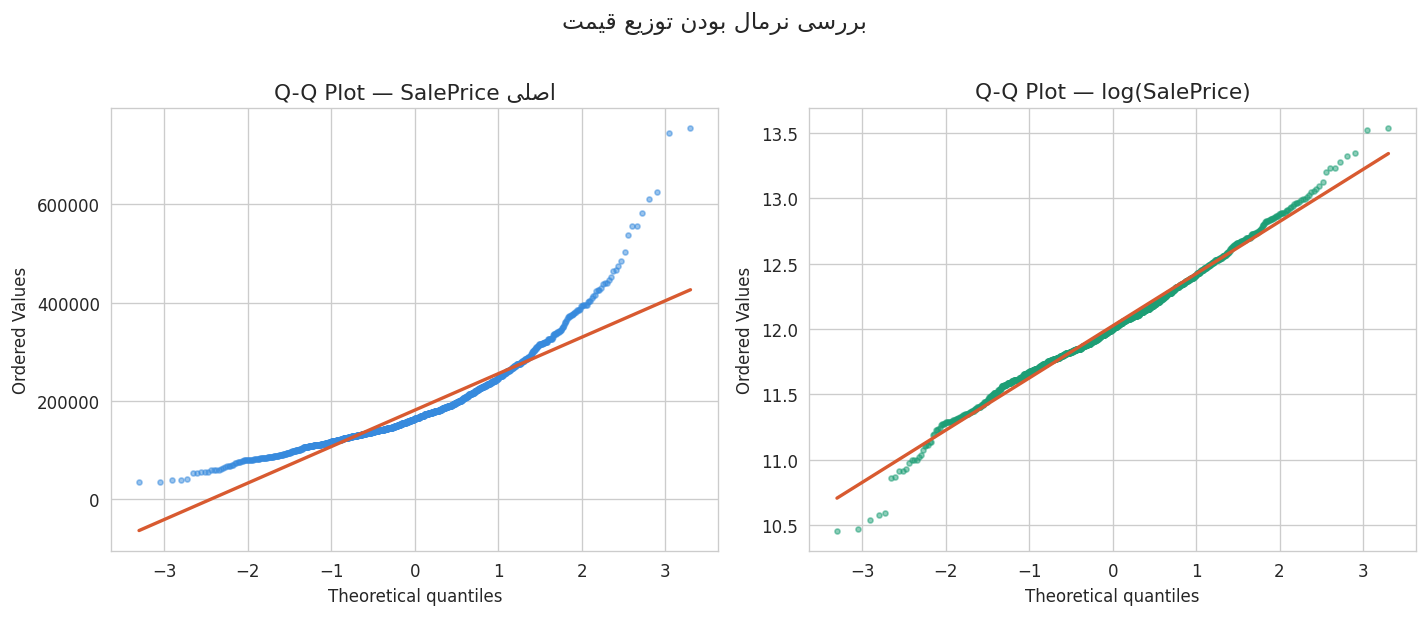

Shapiro-Wilk Test:  p-value = 0.000000
→ توزیع نرمال نیست

Shapiro-Wilk (log): p-value = 0.003319
→ هنوز نرمال نیست


In [12]:
# 10. Q-Q Plot (بررسی نرمال بودن)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot قیمت اصلی
stats.probplot(df['SalePrice'], dist="norm", plot=axes[0])
axes[0].set_title(fa('Q-Q Plot — SalePrice اصلی'), fontsize=13)
axes[0].get_lines()[0].set(color=BLUE, markersize=3, alpha=0.5)
axes[0].get_lines()[1].set(color=ORANGE, linewidth=2)

# Q-Q plot لگاریتمی
stats.probplot(np.log1p(df['SalePrice']), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot — log(SalePrice)', fontsize=13)
axes[1].get_lines()[0].set(color=GREEN, markersize=3, alpha=0.5)
axes[1].get_lines()[1].set(color=ORANGE, linewidth=2)

plt.suptitle(fa('بررسی نرمال بودن توزیع قیمت'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# تست آماری
stat, p = stats.shapiro(df['SalePrice'].sample(200, random_state=42))
print(f'Shapiro-Wilk Test:  p-value = {p:.6f}')
print('→ توزیع نرمال نیست' if p < 0.05 else '→ توزیع نرمال است')
print()
stat2, p2 = stats.shapiro(np.log1p(df['SalePrice'].sample(200, random_state=42)))
print(f'Shapiro-Wilk (log): p-value = {p2:.6f}')
print('→ بعد از log تبدیل به نرمال شد' if p2 > 0.05 else '→ هنوز نرمال نیست')

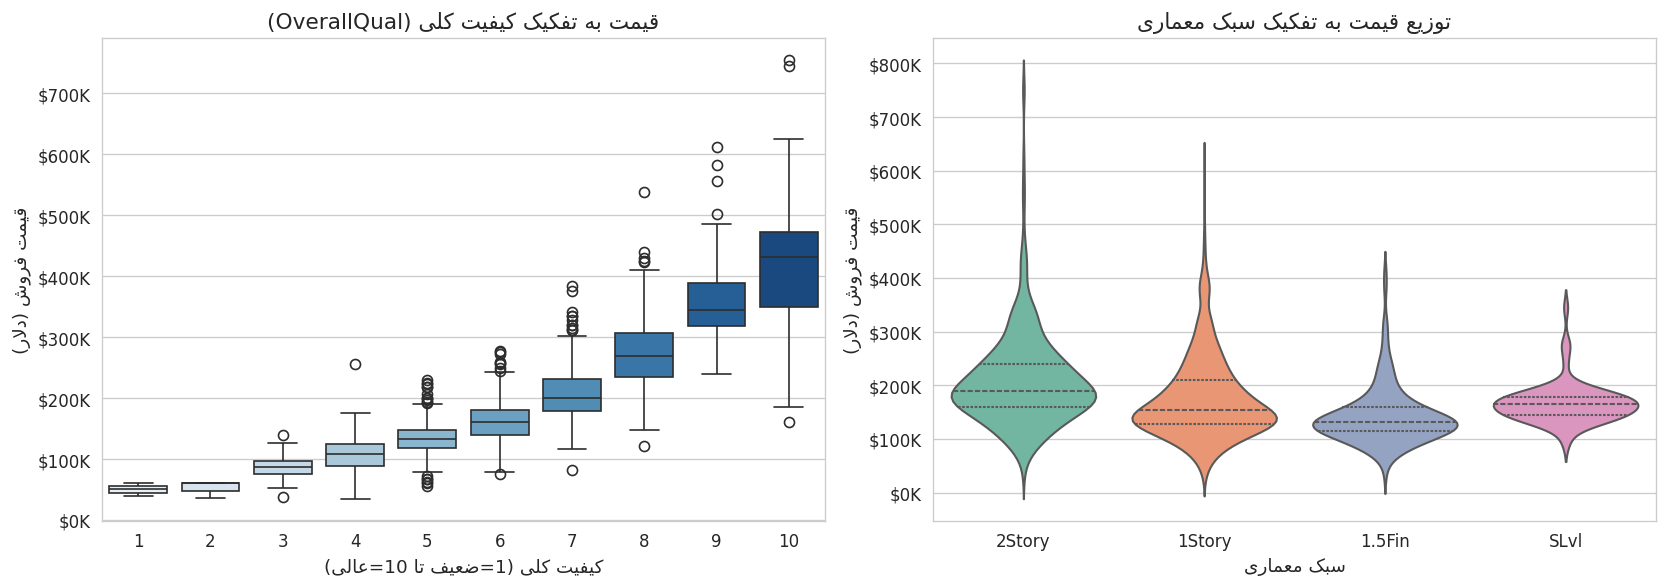

میانه قیمت به تفکیک کیفیت:
OverallQual
1      $50,150
2      $60,000
3      $86,250
4     $108,000
5     $133,000
6     $160,000
7     $200,141
8     $269,750
9     $345,000
10    $432,390


In [13]:
# 11. Boxplot قیمت به تفکیک کیفیت
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot OverallQual vs SalePrice
qual_order = sorted(df['OverallQual'].unique())
sns.boxplot(data=df, x='OverallQual', y='SalePrice', order=qual_order,
            palette='Blues', ax=axes[0])
axes[0].set_title(fa('قیمت به تفکیک کیفیت کلی (OverallQual)'), fontsize=13)
axes[0].set_xlabel(fa('کیفیت کلی (1=ضعیف تا 10=عالی)'), fontsize=11)
axes[0].set_ylabel(fa('قیمت فروش (دلار)'), fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Violin plot سبک معماری vs SalePrice
top_styles = df['HouseStyle'].value_counts().head(4).index
df_styles = df[df['HouseStyle'].isin(top_styles)]
sns.violinplot(data=df_styles, x='HouseStyle', y='SalePrice',
               palette='Set2', ax=axes[1], inner='quartile')
axes[1].set_title(fa('توزیع قیمت به تفکیک سبک معماری'), fontsize=13)
axes[1].set_xlabel(fa('سبک معماری'), fontsize=11)
axes[1].set_ylabel(fa('قیمت فروش (دلار)'), fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# تحلیل
print('میانه قیمت به تفکیک کیفیت:')
print(df.groupby('OverallQual')['SalePrice'].median().apply(lambda x: f'${x:,.0f}').to_string())

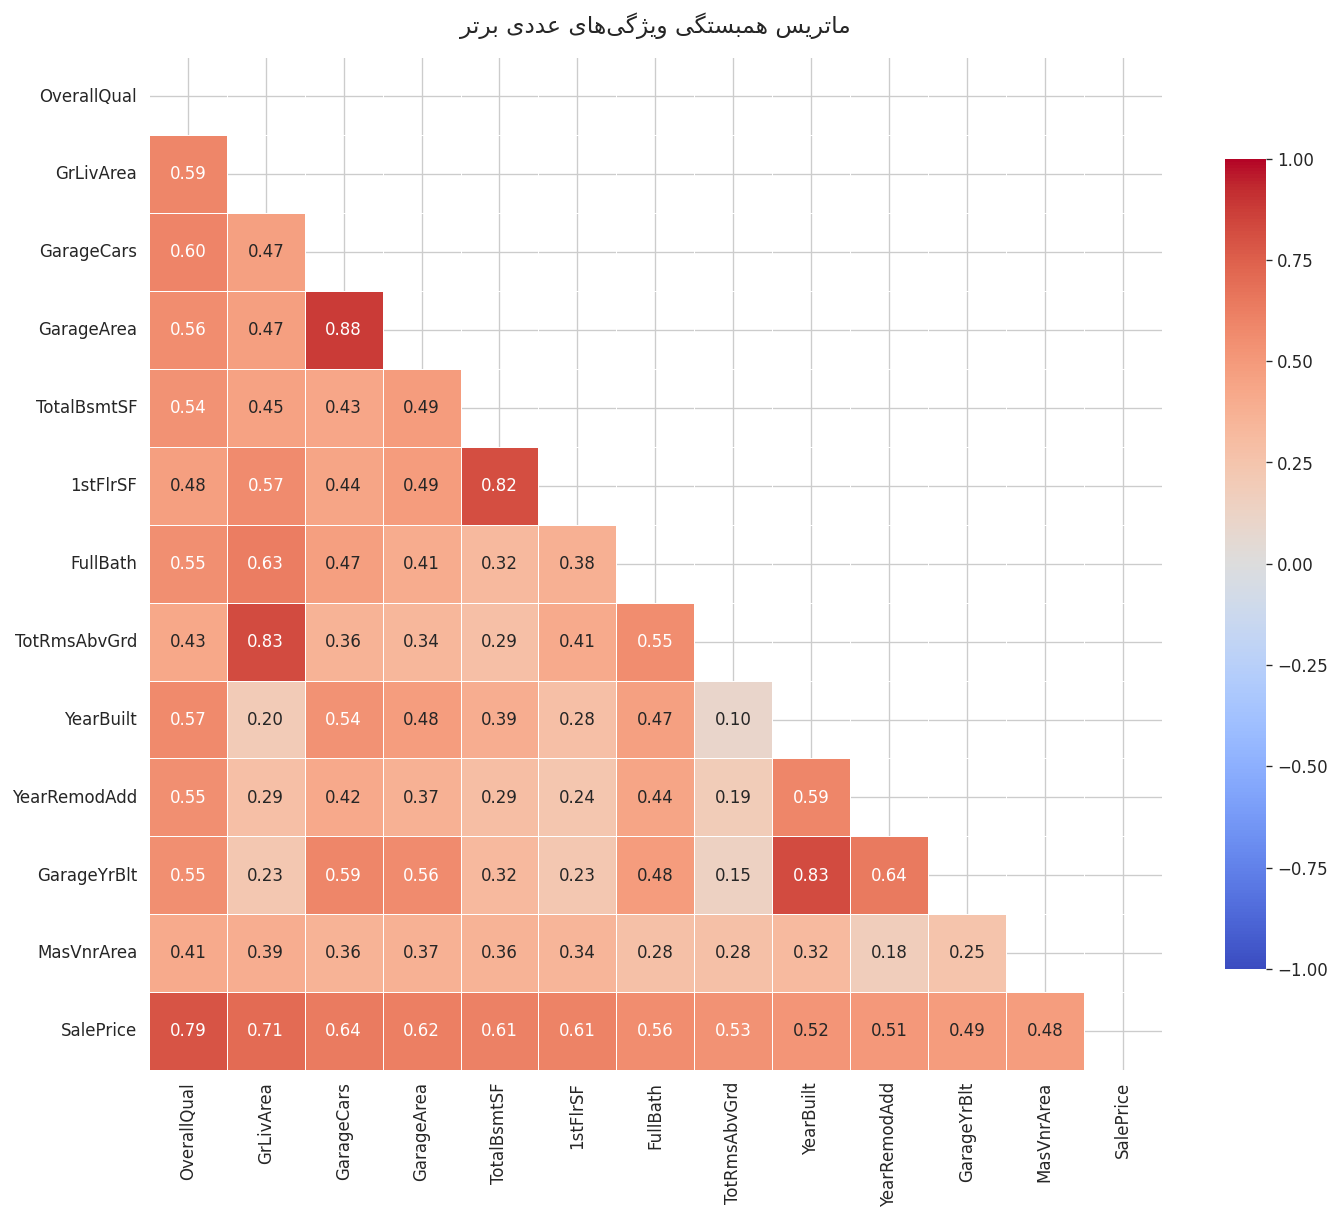

نکته: رنگ قرمز = همبستگی مثبت قوی، آبی = همبستگی منفی
بالاترین همبستگی با SalePrice: OverallQual (0.79)
GrLivArea و TotRmsAbvGrd همبستگی 0.83 با هم دارن → multicollinearity


In [14]:
# 12. Heatmap همبستگی کامل
# انتخاب ویژگی‌های عددی با بالاترین همبستگی
top_features = corr.abs().sort_values(ascending=False).head(12).index.tolist()
top_features.append('SalePrice')
top_features = list(dict.fromkeys(top_features))  

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title(fa('ماتریس همبستگی ویژگی‌های عددی برتر'), fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print('نکته: رنگ قرمز = همبستگی مثبت قوی، آبی = همبستگی منفی')
print(f'بالاترین همبستگی با SalePrice: OverallQual ({corr["OverallQual"]:.2f})')
print(f'GrLivArea و TotRmsAbvGrd همبستگی {df[["GrLivArea","TotRmsAbvGrd"]].corr().iloc[0,1]:.2f} با هم دارن → multicollinearity')

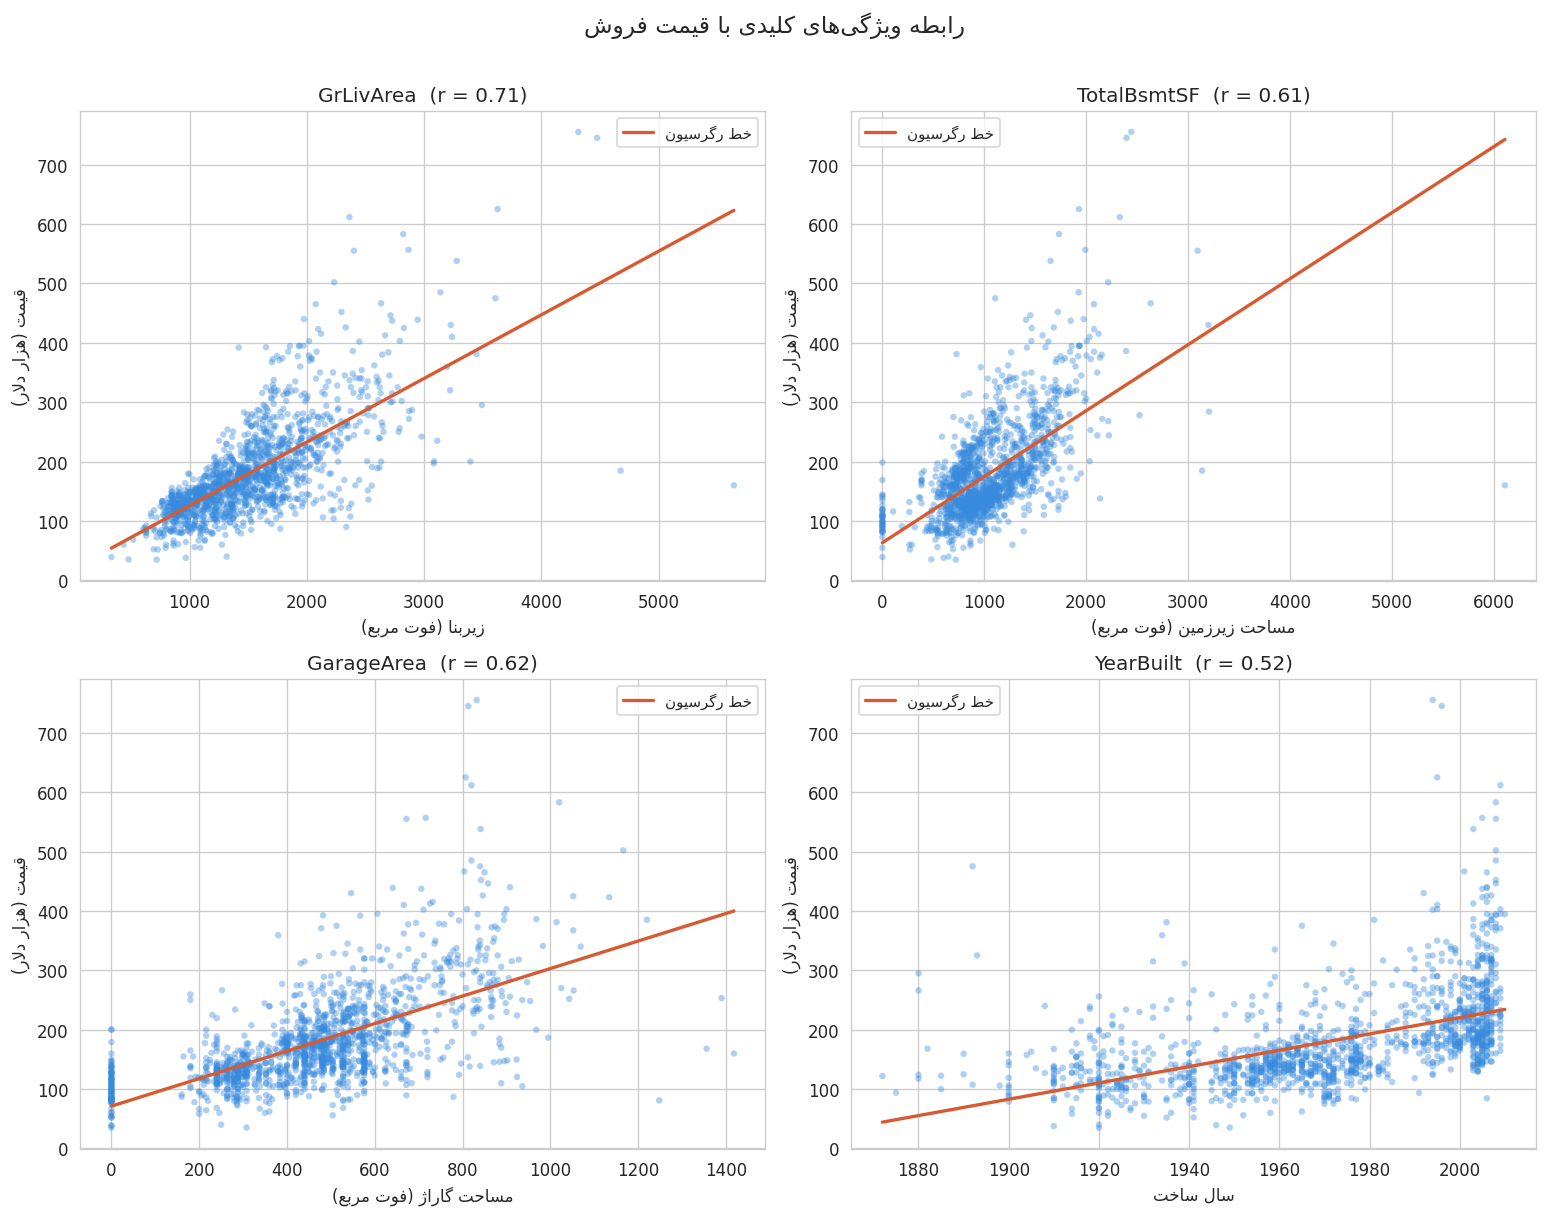

In [15]:
# 13. Scatter Plot ویژگی‌های کلیدی
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

pairs = [
    ('GrLivArea',   fa('زیربنا (فوت مربع)')),
    ('TotalBsmtSF', fa('مساحت زیرزمین (فوت مربع)')),
    ('GarageArea',  fa('مساحت گاراژ (فوت مربع)')),
    ('YearBuilt',   fa('سال ساخت')),
]

for ax, (col, label) in zip(axes.flatten(), pairs):
    ax.scatter(df[col], df['SalePrice'] / 1000,
               alpha=0.4, s=15, color=BLUE, edgecolors='none')

    # خط رگرسیون
    mask_valid = df[col].notna()
    z = np.polyfit(df.loc[mask_valid, col], df.loc[mask_valid, 'SalePrice'] / 1000, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p_line(x_line), color=ORANGE, linewidth=2, label=fa('خط رگرسیون'))

    r = df[[col, 'SalePrice']].corr().iloc[0, 1]
    ax.set_title(f'{col}  (r = {r:.2f})', fontsize=12)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel(fa('قیمت (هزار دلار)'), fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle(fa('رابطه ویژگی‌های کلیدی با قیمت فروش'), fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 🧹 پاکسازی داده‌ها (Data Cleaning): در این بخش مقادیر گمشده، داده‌های پرت و مشکلات نوع داده برطرف می‌شوند.
1. *مقادیر گمشده — پر کردن یا حذف***
2. *Outlier — شناسایی و حذف***
3. *ویژگی‌های بی‌فایده — حذف ستون‌هایی که اطلاعات مفید ندارن***
4. *تبدیل نوع داده — مثل MSSubClass که عددیه ولی باید categorical باشه***

In [16]:
# 1. ذخیره نسخه اصلی + شروع پاکسازی
df_raw = df.copy()
df_clean = df.copy()
print(f'✅ نسخه اصلی ذخیره شد: {df_raw.shape}')

✅ نسخه اصلی ذخیره شد: (1460, 81)


In [17]:
# 2. پر کردن missing values
# ستون‌هایی که NA یعنی «ندارم» — با None پر می‌شن
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 
             'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
             'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df_clean[col] = df_clean[col].fillna('None')

# ستون‌های عددی گاراژ — با 0 پر می‌شن
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    df_clean[col] = df_clean[col].fillna(0)

# LotFrontage — با میانه همون محله پر می‌شه
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage']\
                           .transform(lambda x: x.fillna(x.median()))

# Electrical — فقط ۱ تا NA داره، با مد پر می‌شه
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# چک کردن نتیجه
remaining = df_clean.isnull().sum().sum()
print(f'مقادیر گمشده قبل از پاکسازی: {df_raw.isnull().sum().sum()}')
print(f'مقادیر گمشده بعد از پاکسازی: {remaining}')

مقادیر گمشده قبل از پاکسازی: 7829
مقادیر گمشده بعد از پاکسازی: 0


In [18]:
# 3. حذف Outlier
# شناسایی outlier با IQR روی GrLivArea و SalePrice
def remove_outliers_iqr(data, col, factor=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

before = len(df_clean)
df_clean = remove_outliers_iqr(df_clean, 'GrLivArea')
df_clean = remove_outliers_iqr(df_clean, 'SalePrice')
after = len(df_clean)

print(f'تعداد قبل از حذف outlier: {before}')
print(f'تعداد بعد از حذف outlier:  {after}')
print(f'تعداد ردیف حذف شده:        {before - after}')

تعداد قبل از حذف outlier: 1460
تعداد بعد از حذف outlier:  1373
تعداد ردیف حذف شده:        87


In [19]:
# 4. تبدیل نوع داده
# MSSubClass عددیه ولی باید categorical باشه
df_clean['MSSubClass'] = df_clean['MSSubClass'].astype(str)
df_raw['MSSubClass']   = df_raw['MSSubClass'].astype(str)

print('✅ MSSubClass به string تبدیل شد')

✅ MSSubClass به string تبدیل شد


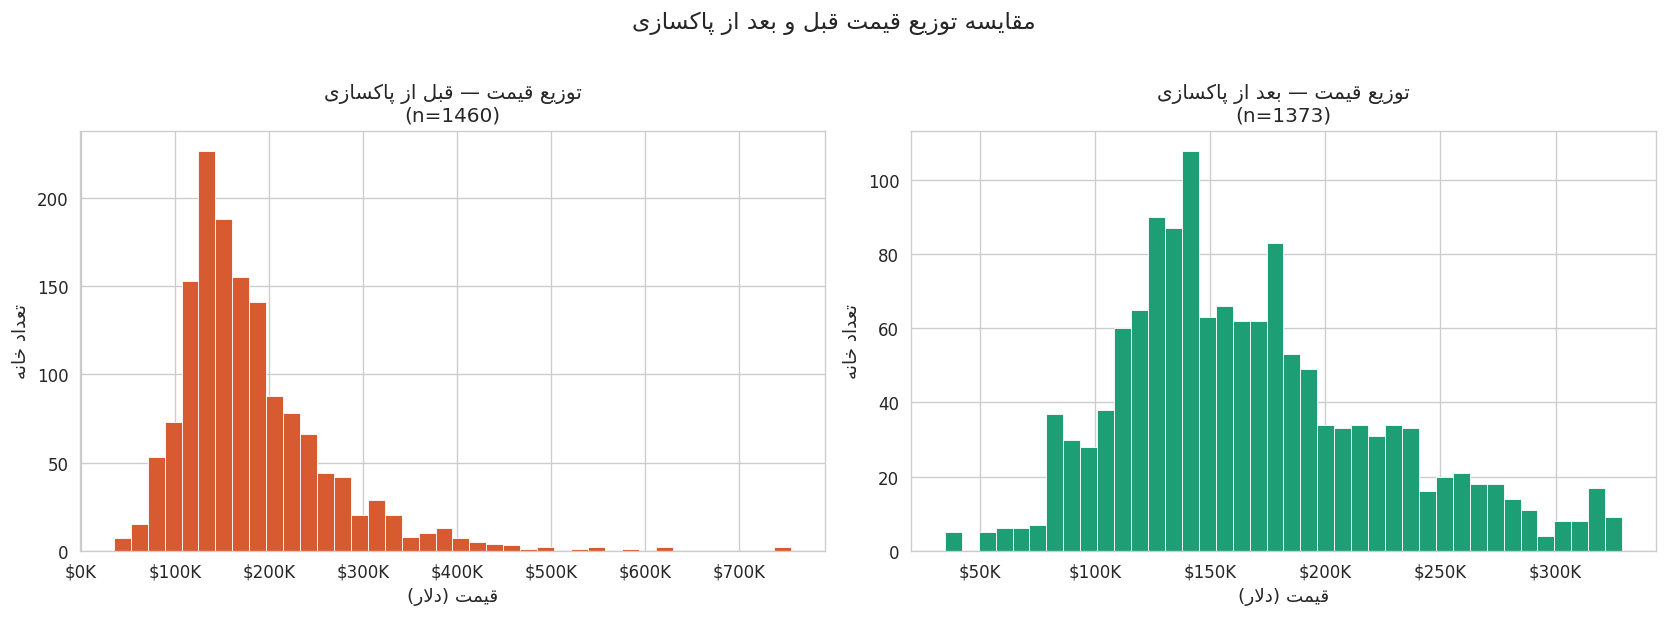

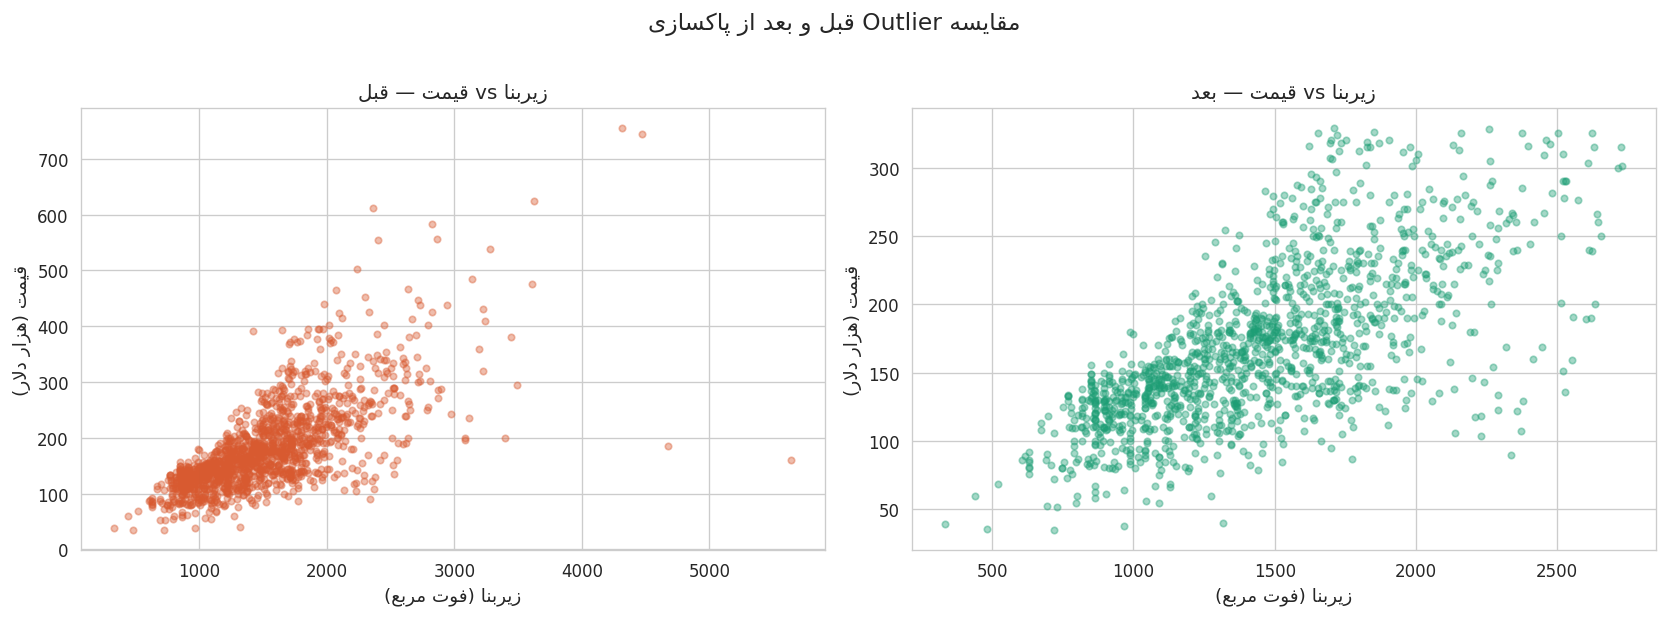

خلاصه پاکسازی:
  - مقادیر گمشده: 7829 → 0
  - تعداد ردیف‌ها: 1460 → 1373
  - MSSubClass به categorical تبدیل شد


In [20]:
# 5.  مقایسه قبل و بعد (بصری)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# قبل از پاکسازی
axes[0].hist(df_raw['SalePrice'], bins=40, color=ORANGE, edgecolor='white', linewidth=0.5)
axes[0].set_title(fa('توزیع قیمت — قبل از پاکسازی'), fontsize=13)
axes[0].set_xlabel(fa('قیمت (دلار)'), fontsize=11)
axes[0].set_ylabel(fa('تعداد خانه'), fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title(axes[0].get_title() + f'\n(n={len(df_raw)})', fontsize=12)

# بعد از پاکسازی
axes[1].hist(df_clean['SalePrice'], bins=40, color=GREEN, edgecolor='white', linewidth=0.5)
axes[1].set_title(fa('توزیع قیمت — بعد از پاکسازی'), fontsize=13)
axes[1].set_xlabel(fa('قیمت (دلار)'), fontsize=11)
axes[1].set_ylabel(fa('تعداد خانه'), fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_title(axes[1].get_title() + f'\n(n={len(df_clean)})', fontsize=12)

plt.suptitle(fa('مقایسه توزیع قیمت قبل و بعد از پاکسازی'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# مقایسه outlier — scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_raw['GrLivArea'], df_raw['SalePrice']/1000,
                alpha=0.4, s=15, color=ORANGE)
axes[0].set_title(fa('زیربنا vs قیمت — قبل'), fontsize=12)
axes[0].set_xlabel(fa('زیربنا (فوت مربع)'), fontsize=11)
axes[0].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)

axes[1].scatter(df_clean['GrLivArea'], df_clean['SalePrice']/1000,
                alpha=0.4, s=15, color=GREEN)
axes[1].set_title(fa('زیربنا vs قیمت — بعد'), fontsize=12)
axes[1].set_xlabel(fa('زیربنا (فوت مربع)'), fontsize=11)
axes[1].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)

plt.suptitle(fa('مقایسه Outlier قبل و بعد از پاکسازی'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'خلاصه پاکسازی:')
print(f'  - مقادیر گمشده: {df_raw.isnull().sum().sum()} → {df_clean.isnull().sum().sum()}')
print(f'  - تعداد ردیف‌ها: {len(df_raw)} → {len(df_clean)}')
print(f'  - MSSubClass به categorical تبدیل شد')

## 🔍 تحلیل اکتشافی داده‌ها (EDA): در این بخش نمودارهای تحلیلی پیشرفته برای کشف بینش‌های عمیق‌تر ارائه می‌شود.

In [21]:
# 1. آمار توصیفی کامل
print('=== آمار توصیفی ویژگی‌های عددی ===')
df_clean[num_cols].describe().round(2)

=== آمار توصیفی ویژگی‌های عددی ===


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,...,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00,1373.00
mean,68.75,10021.90,5.95,5.59,1970.07,1983.85,86.72,407.80,47.27,557.88,...,454.41,88.14,43.25,22.16,3.29,14.11,1.43,43.95,6.32,2007.82
std,20.62,8197.74,1.26,1.11,29.82,20.72,153.90,399.63,162.96,428.54,...,200.12,119.69,61.72,60.04,28.83,52.36,30.71,507.88,2.71,1.33
min,21.00,1300.00,1.00,1.00,1872.00,1950.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2006.00
25%,60.00,7399.00,5.00,5.00,1953.00,1965.00,0.00,0.00,0.00,218.00,...,312.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,2007.00
50%,70.00,9245.00,6.00,5.00,1971.00,1992.00,0.00,361.00,0.00,474.00,...,463.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,6.00,2008.00
75%,80.00,11248.00,7.00,6.00,1999.00,2003.00,136.00,678.00,0.00,803.00,...,570.00,164.00,63.00,0.00,0.00,0.00,0.00,0.00,8.00,2009.00
max,313.00,164660.00,10.00,9.00,2009.00,2010.00,1600.00,1880.00,1474.00,2042.00,...,1390.00,736.00,523.00,386.00,508.00,396.00,738.00,15500.00,12.00,2010.00


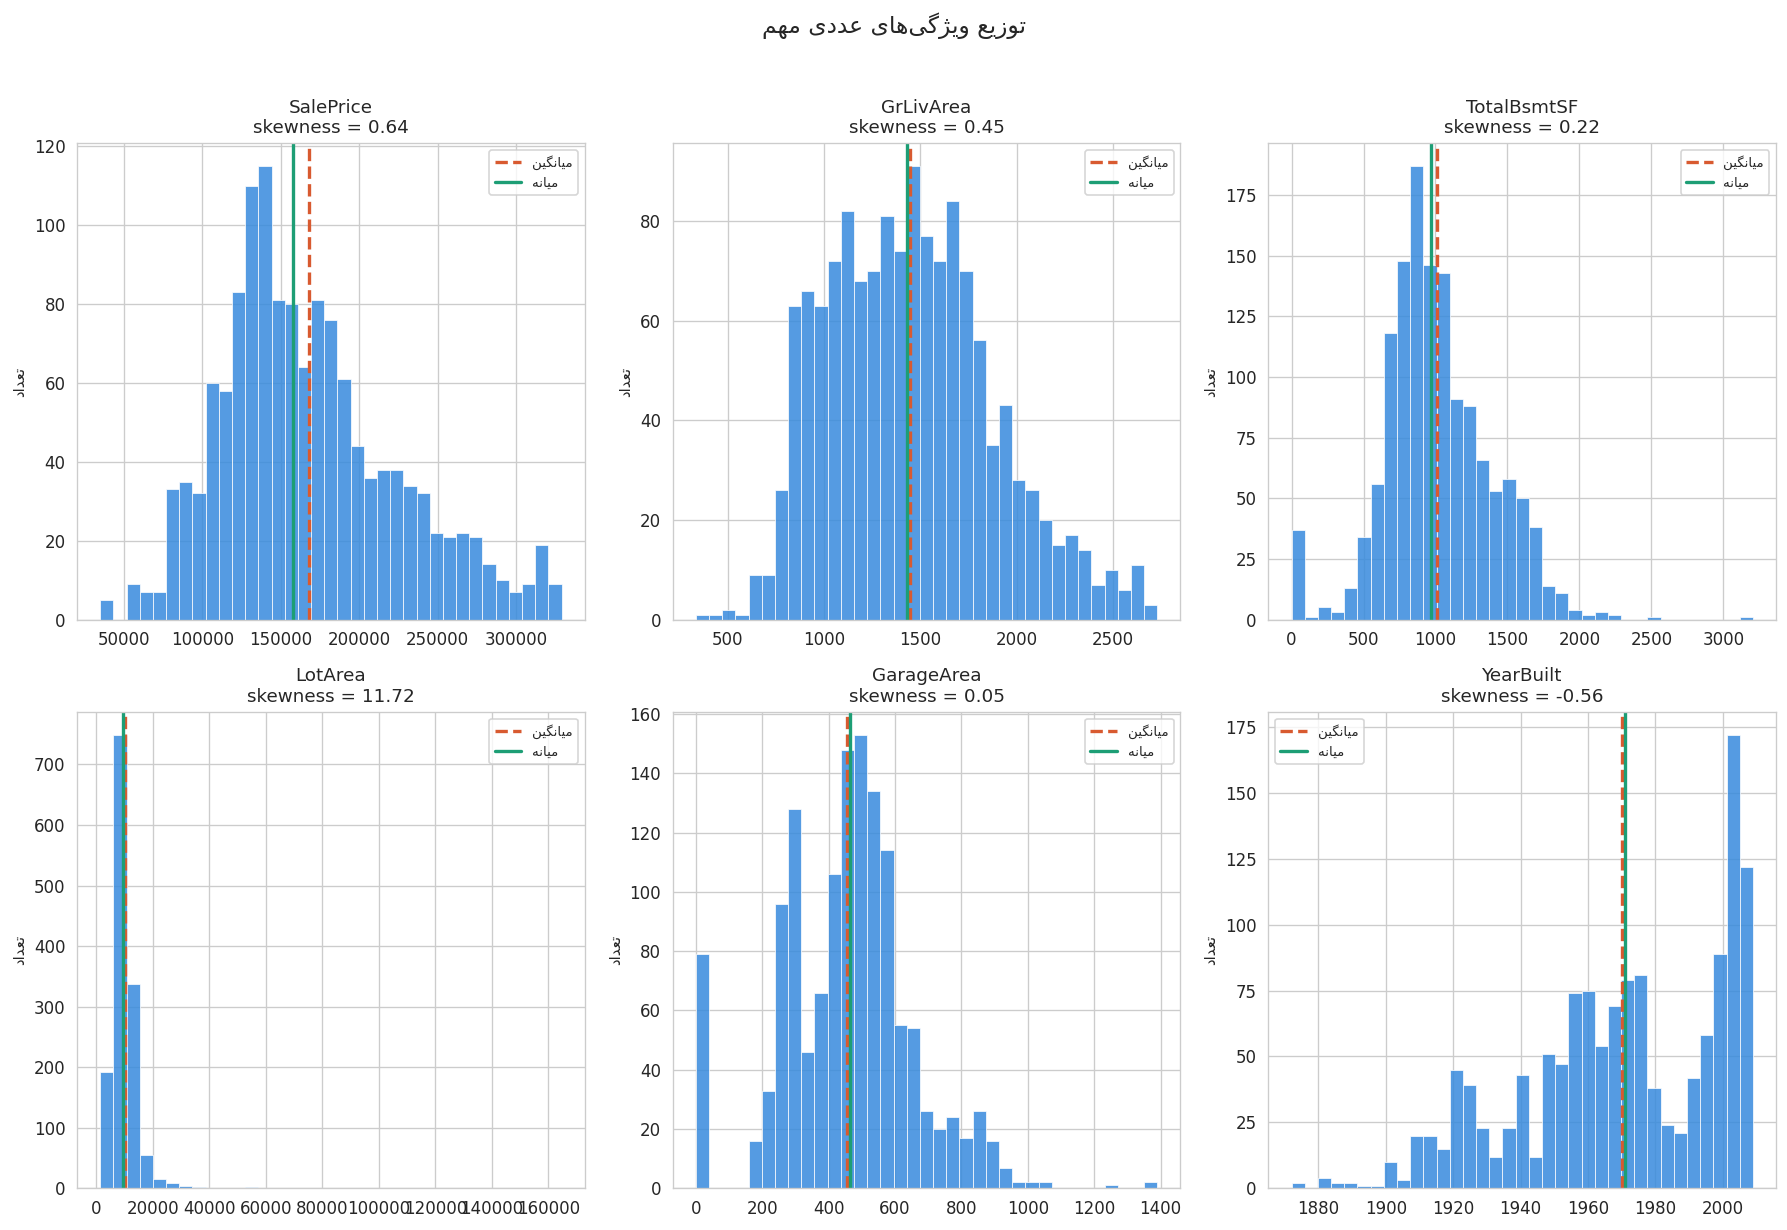

In [22]:
# 2. توزیع ویژگی‌های عددی مهم
important_num = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 
                 'LotArea', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, col in zip(axes.flatten(), important_num):
    skew = df_clean[col].skew()
    ax.hist(df_clean[col], bins=35, color=BLUE, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.axvline(df_clean[col].mean(),   color=ORANGE, linewidth=2, linestyle='--', label=fa('میانگین'))
    ax.axvline(df_clean[col].median(), color=GREEN,  linewidth=2, linestyle='-',  label=fa('میانه'))
    ax.set_title(f'{col}\nskewness = {skew:.2f}', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylabel(fa('تعداد'), fontsize=9)

plt.suptitle(fa('توزیع ویژگی‌های عددی مهم'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

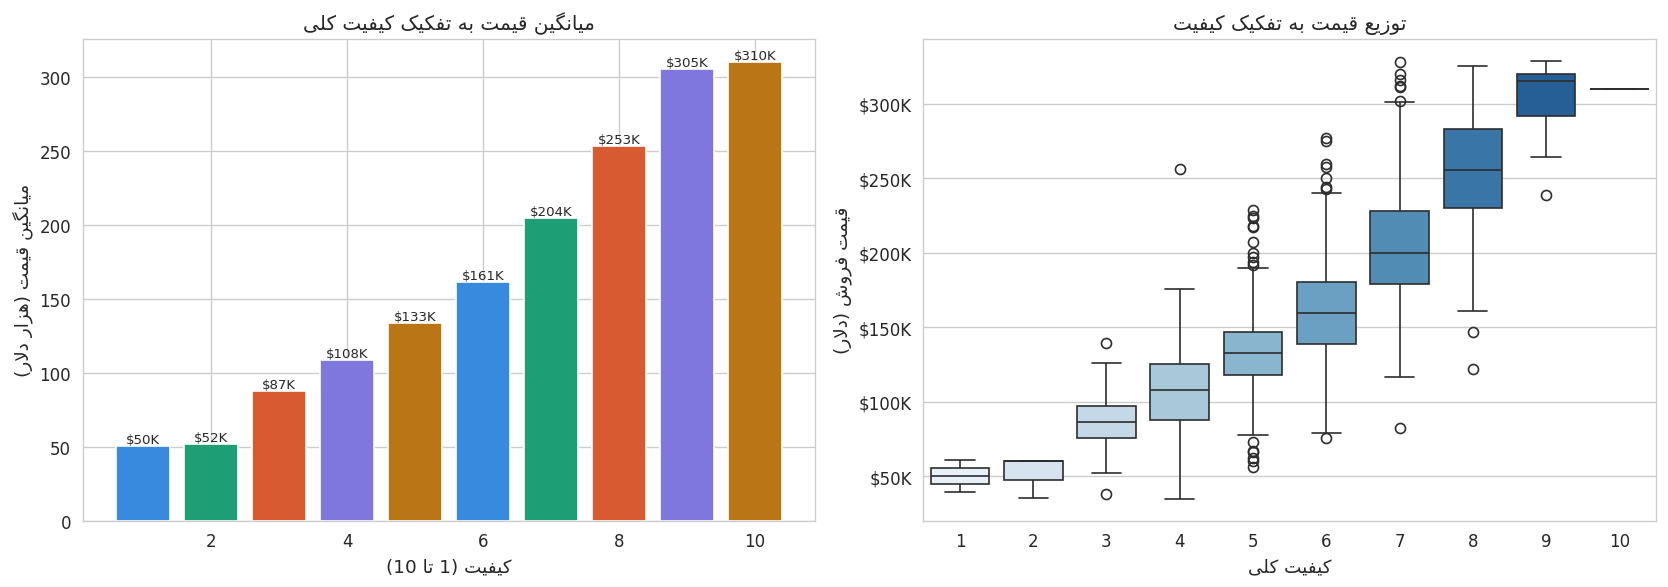

نتیجه: با افزایش هر سطح کیفیت، قیمت به طور میانگین:
  حداقل افزایش: $2K
  حداکثر افزایش: $52K


In [23]:
# 3. تأثیر کیفیت کلی روی قیمت
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# میانگین قیمت به تفکیک کیفیت
qual_mean = df_clean.groupby('OverallQual')['SalePrice'].mean() / 1000
axes[0].bar(qual_mean.index, qual_mean.values, color=PALETTE * 2, edgecolor='white')
for i, (q, v) in enumerate(qual_mean.items()):
    axes[0].text(q, v + 2, f'${v:.0f}K', ha='center', fontsize=8)
axes[0].set_title(fa('میانگین قیمت به تفکیک کیفیت کلی'), fontsize=12)
axes[0].set_xlabel(fa('کیفیت (1 تا 10)'), fontsize=11)
axes[0].set_ylabel(fa('میانگین قیمت (هزار دلار)'), fontsize=11)

# boxplot
sns.boxplot(data=df_clean, x='OverallQual', y='SalePrice',
            palette='Blues', ax=axes[1])
axes[1].set_title(fa('توزیع قیمت به تفکیک کیفیت'), fontsize=12)
axes[1].set_xlabel(fa('کیفیت کلی'), fontsize=11)
axes[1].set_ylabel(fa('قیمت فروش (دلار)'), fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

print('نتیجه: با افزایش هر سطح کیفیت، قیمت به طور میانگین:')
diffs = qual_mean.diff().dropna()
print(f'  حداقل افزایش: ${diffs.min():.0f}K')
print(f'  حداکثر افزایش: ${diffs.max():.0f}K')

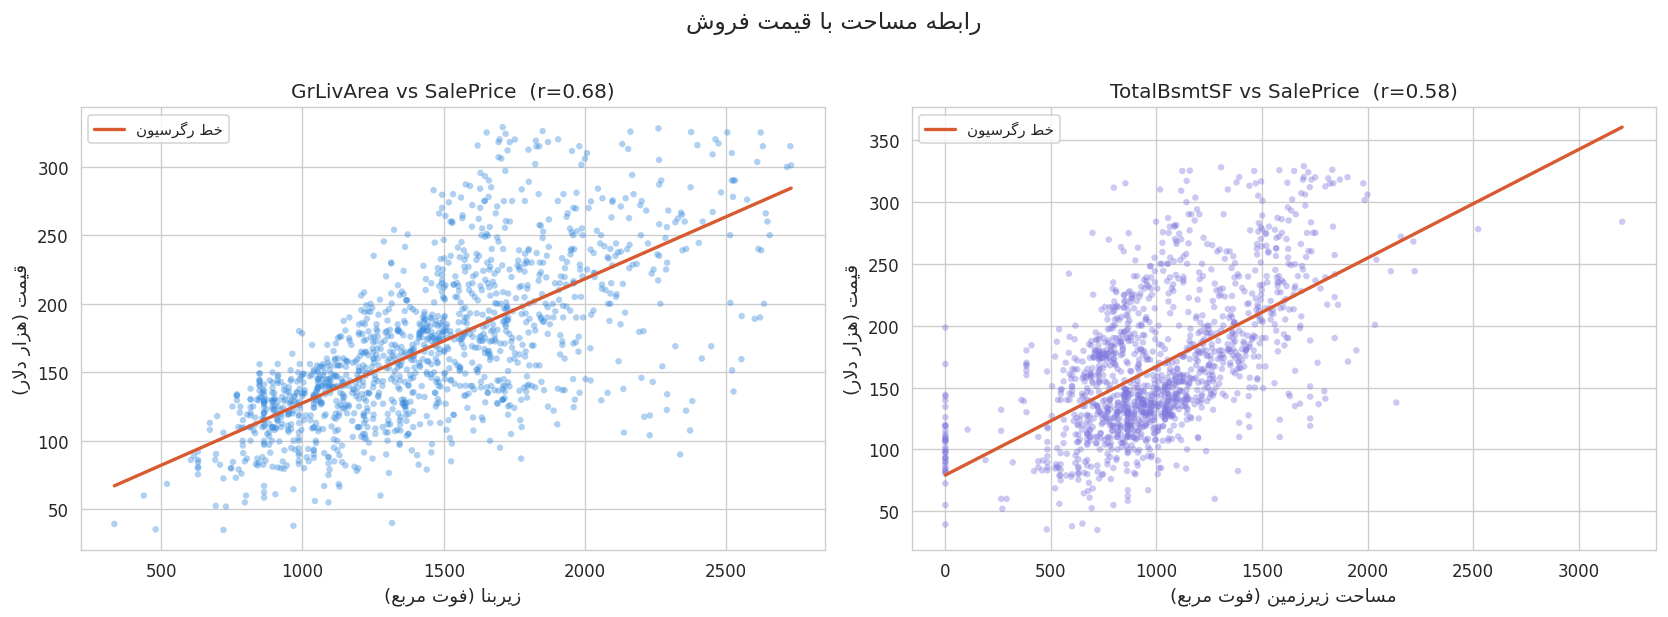

هر ۱۰۰ فوت مربع افزایش زیربنا → قیمت ~$9K بالا میره
همبستگی زیرزمین با قیمت: 0.58 — رابطه مثبت ولی ضعیف‌تر از زیربنا


In [24]:
# 4. رابطه مساحت و قیمت
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GrLivArea vs SalePrice
axes[0].scatter(df_clean['GrLivArea'], df_clean['SalePrice']/1000,
                alpha=0.4, s=15, color=BLUE, edgecolors='none')
z = np.polyfit(df_clean['GrLivArea'], df_clean['SalePrice']/1000, 1)
x_line = np.linspace(df_clean['GrLivArea'].min(), df_clean['GrLivArea'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color=ORANGE, linewidth=2, label=fa('خط رگرسیون'))
r = df_clean[['GrLivArea','SalePrice']].corr().iloc[0,1]
axes[0].set_title(f'GrLivArea vs SalePrice  (r={r:.2f})', fontsize=12)
axes[0].set_xlabel(fa('زیربنا (فوت مربع)'), fontsize=11)
axes[0].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)
axes[0].legend(fontsize=9)

# TotalBsmtSF vs SalePrice
axes[1].scatter(df_clean['TotalBsmtSF'], df_clean['SalePrice']/1000,
                alpha=0.4, s=15, color=PURPLE, edgecolors='none')
z2 = np.polyfit(df_clean['TotalBsmtSF'], df_clean['SalePrice']/1000, 1)
x_line2 = np.linspace(df_clean['TotalBsmtSF'].min(), df_clean['TotalBsmtSF'].max(), 100)
axes[1].plot(x_line2, np.poly1d(z2)(x_line2), color=ORANGE, linewidth=2, label=fa('خط رگرسیون'))
r2 = df_clean[['TotalBsmtSF','SalePrice']].corr().iloc[0,1]
axes[1].set_title(f'TotalBsmtSF vs SalePrice  (r={r2:.2f})', fontsize=12)
axes[1].set_xlabel(fa('مساحت زیرزمین (فوت مربع)'), fontsize=11)
axes[1].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle(fa('رابطه مساحت با قیمت فروش'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f'هر ۱۰۰ فوت مربع افزایش زیربنا → قیمت ~${z[0]*100:.0f}K بالا میره')
print(f'همبستگی زیرزمین با قیمت: {r2:.2f} — رابطه مثبت ولی ضعیف‌تر از زیربنا')

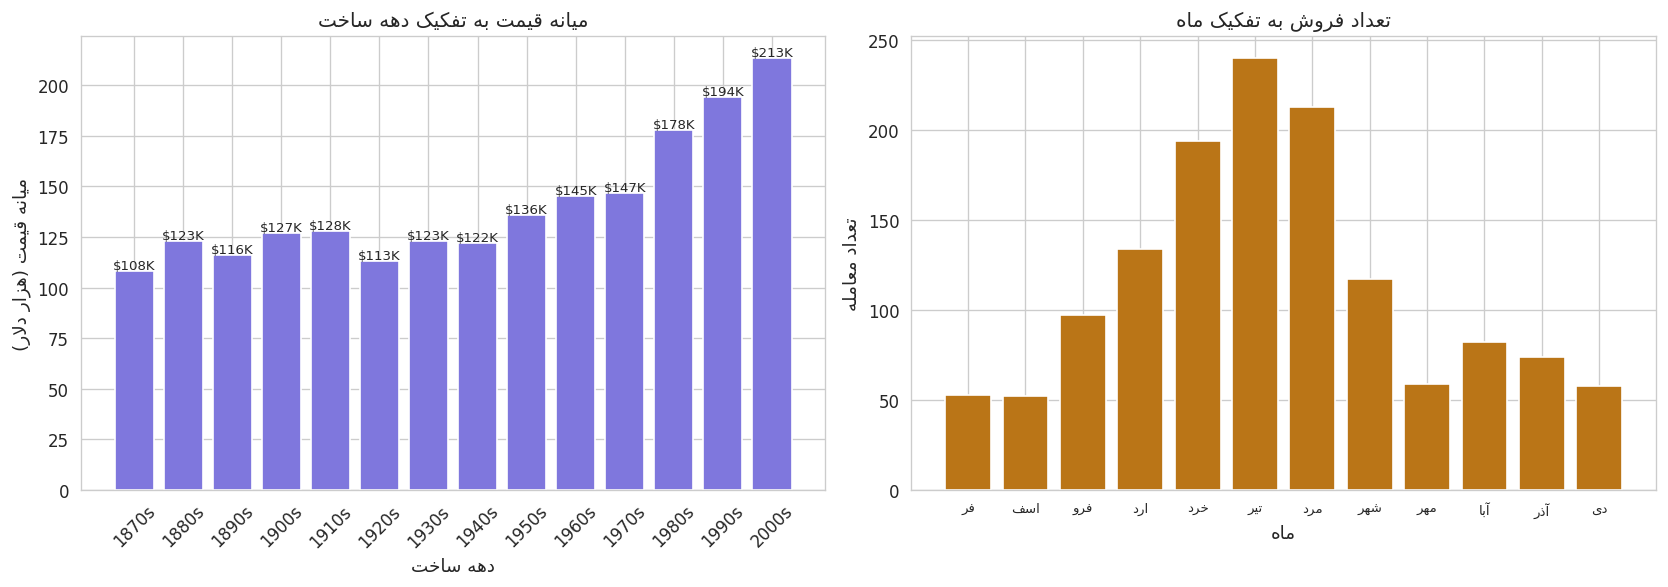

پرفروش‌ترین ماه: ماه 6 با 240 معامله
کم‌فروش‌ترین ماه: ماه 2 با 52 معامله


In [25]:
# 5.  تحلیل زمانی
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# قیمت به تفکیک سال ساخت (میانگین هر دهه)
df_clean['Decade'] = (df_clean['YearBuilt'] // 10 * 10).astype(str) + 's'
decade_price = df_clean.groupby('Decade')['SalePrice'].median() / 1000
axes[0].bar(decade_price.index, decade_price.values, color=PURPLE, edgecolor='white')
axes[0].set_title(fa('میانه قیمت به تفکیک دهه ساخت'), fontsize=12)
axes[0].set_xlabel(fa('دهه ساخت'), fontsize=11)
axes[0].set_ylabel(fa('میانه قیمت (هزار دلار)'), fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(decade_price.values):
    axes[0].text(i, v + 1, f'${v:.0f}K', ha='center', fontsize=8)

# تعداد فروش به تفکیک ماه
month_count = df_clean['MoSold'].value_counts().sort_index()
month_names = ['فر', 'اسف', 'فرو', 'ارد', 'خرد', 'تیر', 'مرد', 'شهر', 'مهر', 'آبا', 'آذر', 'دی']
axes[1].bar(range(1,13), month_count.values, color=AMBER, edgecolor='white')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels([fa(m) for m in month_names], fontsize=8)
axes[1].set_title(fa('تعداد فروش به تفکیک ماه'), fontsize=12)
axes[1].set_xlabel(fa('ماه'), fontsize=11)
axes[1].set_ylabel(fa('تعداد معامله'), fontsize=11)

plt.tight_layout()
plt.show()

print(f'پرفروش‌ترین ماه: ماه {month_count.idxmax()} با {month_count.max()} معامله')
print(f'کم‌فروش‌ترین ماه: ماه {month_count.idxmin()} با {month_count.min()} معامله')

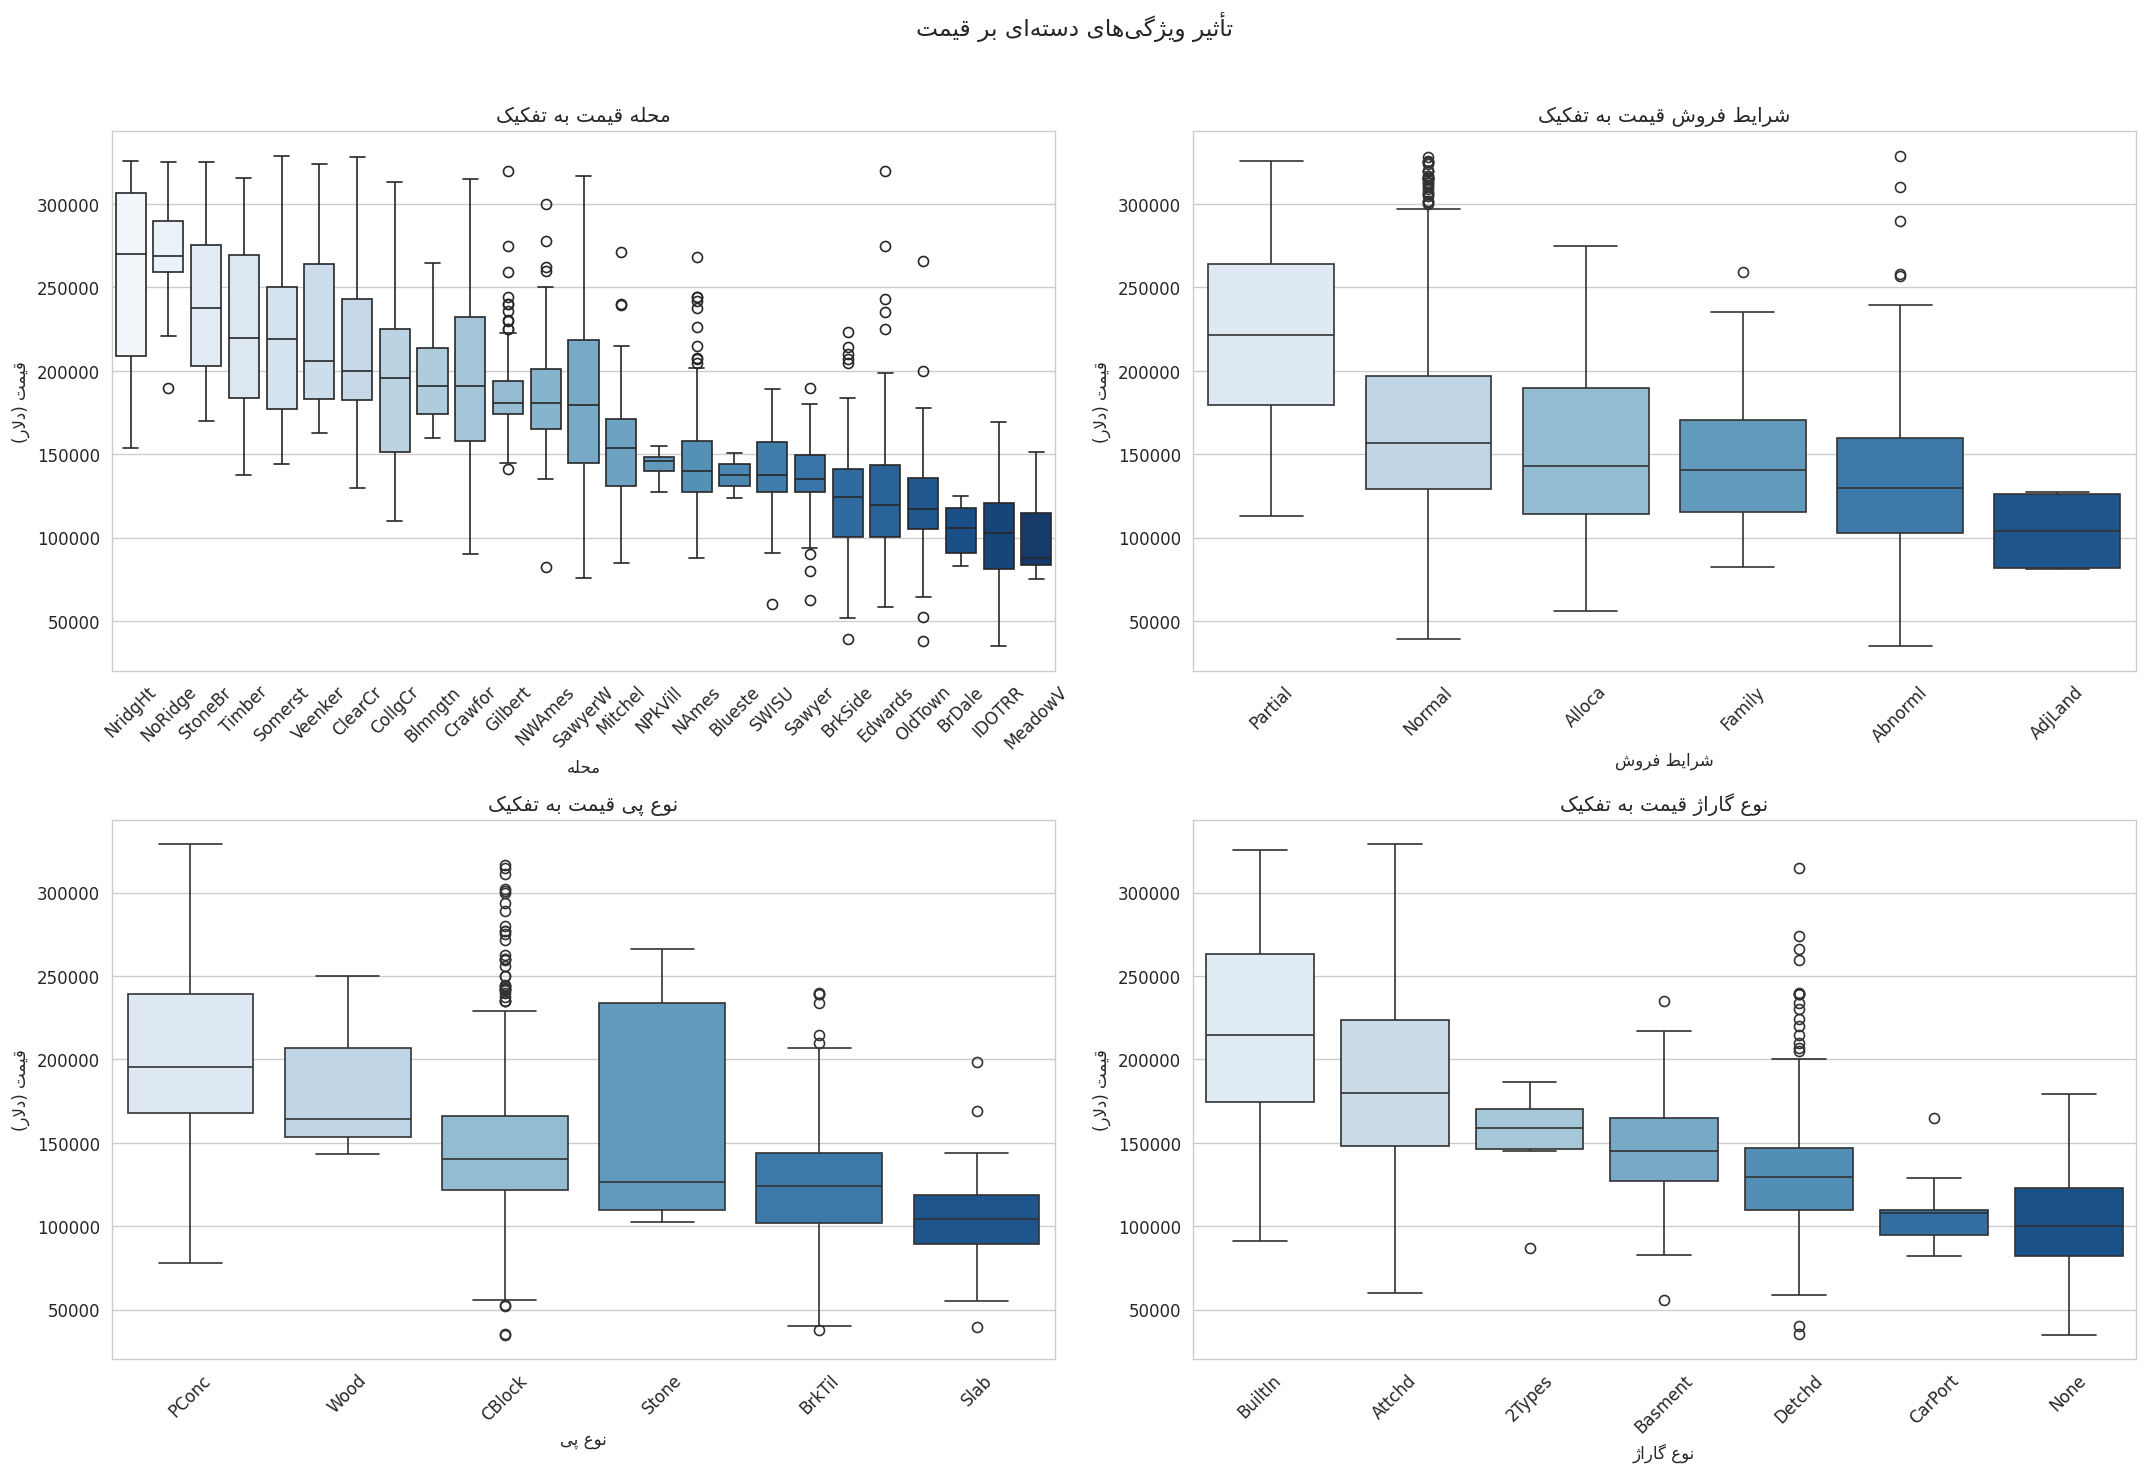

In [26]:
# 6. تحلیل ویژگی‌های categorical
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cats = [
    ('Neighborhood', fa('محله'), 90),
    ('SaleCondition', fa('شرایط فروش'), 20),
    ('Foundation', fa('نوع پی'), 20),
    ('GarageType', fa('نوع گاراژ'), 20),
]

for ax, (col, label, rot) in zip(axes.flatten(), cats):
    order = df_clean.groupby(col)['SalePrice'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_clean,
        x=col,
        y='SalePrice',
        order=order,
        palette='Blues',
        ax=ax
    )

    ax.set_title(f'{fa("قیمت به تفکیک")} {label}', fontsize=12)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel(fa('قیمت (دلار)'), fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(fa('تأثیر ویژگی‌های دسته‌ای بر قیمت'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

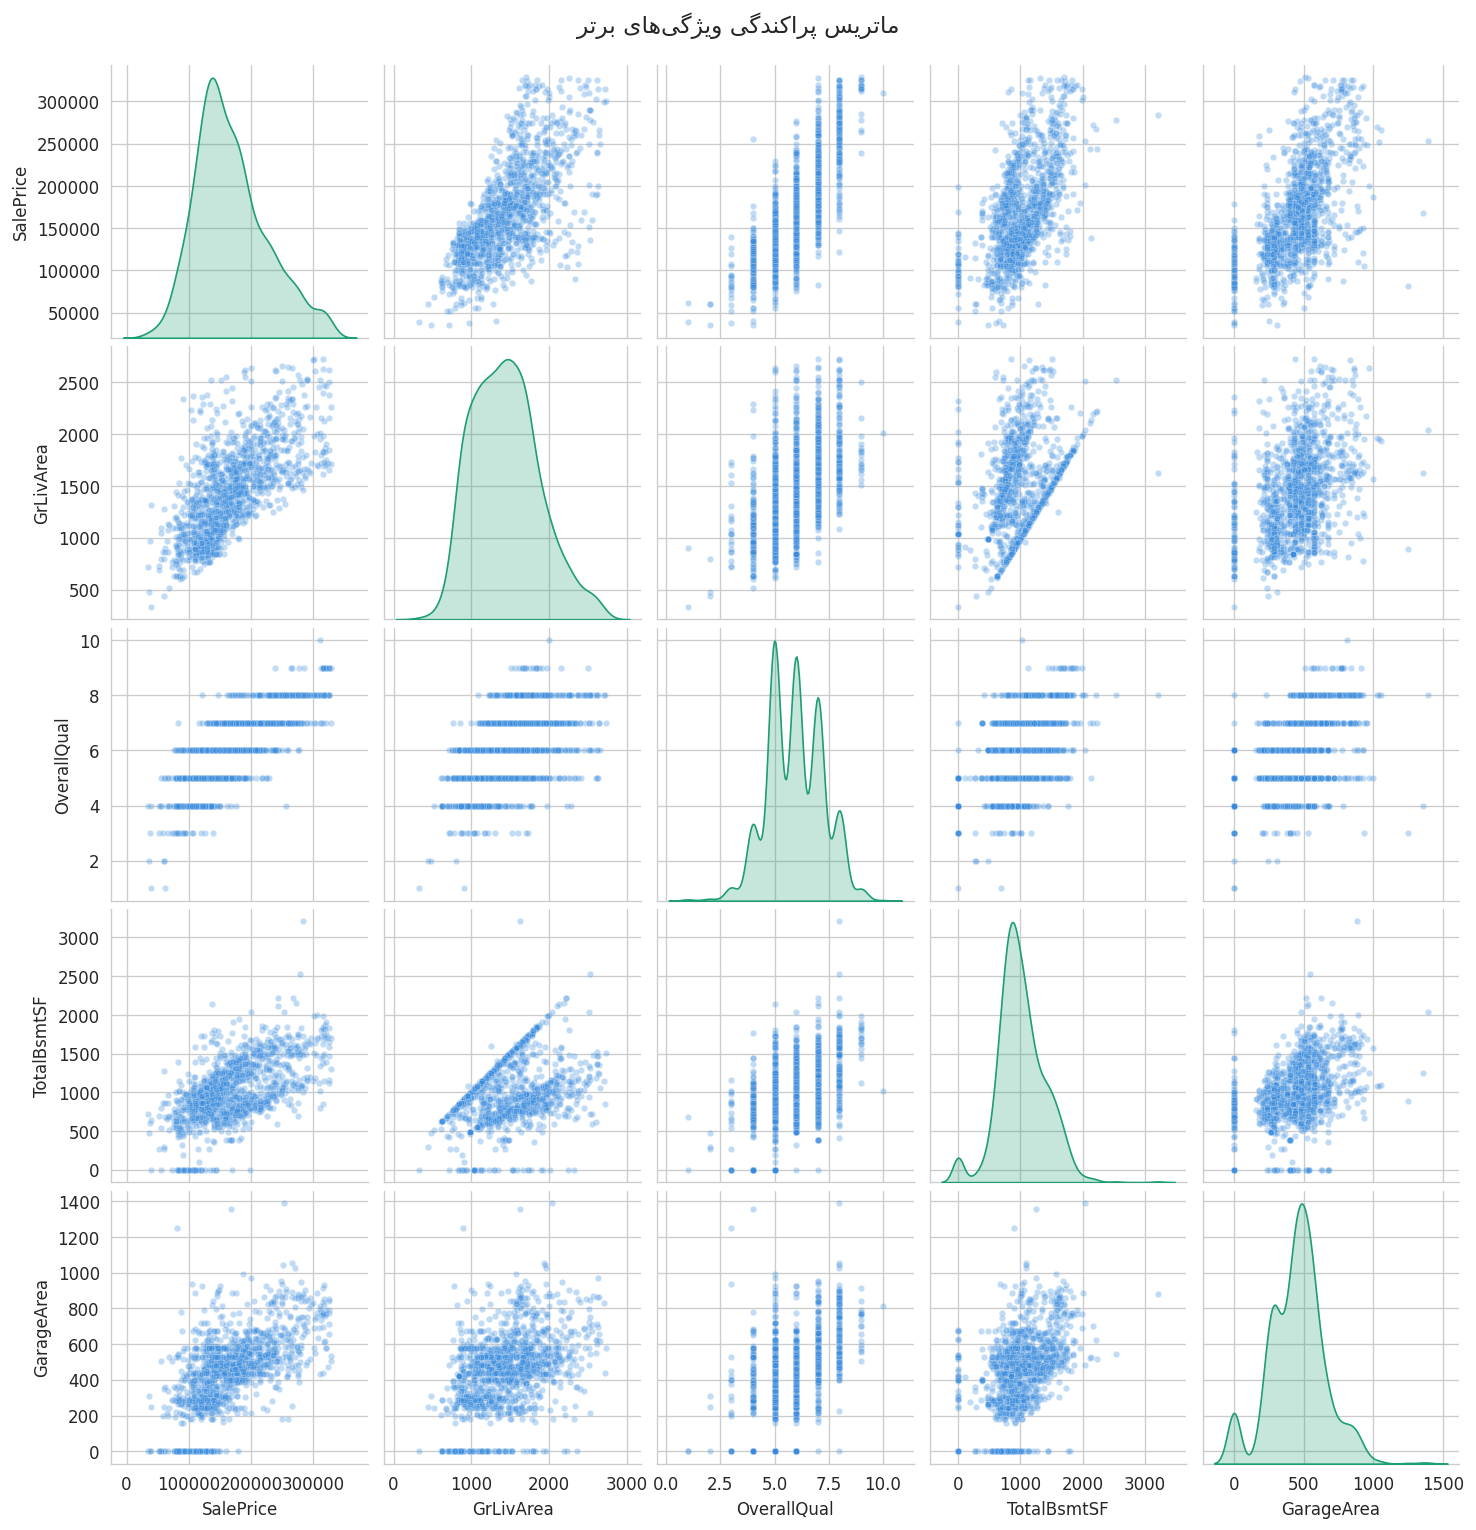

نتیجه: GrLivArea و OverallQual قوی‌ترین رابطه خطی با SalePrice دارن
نتیجه: بین GrLivArea و TotalBsmtSF همبستگی متوسطی وجود داره


In [27]:
# 7. Pairplot ویژگی‌های برتر
top5 = ['SalePrice', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea']

g = sns.pairplot(df_clean[top5], 
                 diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 15, 'color': BLUE},
                 diag_kws={'color': GREEN})

g.fig.suptitle(fa('ماتریس پراکندگی ویژگی‌های برتر'), y=1.02, fontsize=14)
plt.show()
print('نتیجه: GrLivArea و OverallQual قوی‌ترین رابطه خطی با SalePrice دارن')
print('نتیجه: بین GrLivArea و TotalBsmtSF همبستگی متوسطی وجود داره')

## 📊 مصورسازی داده‌ها (Data Visualization)

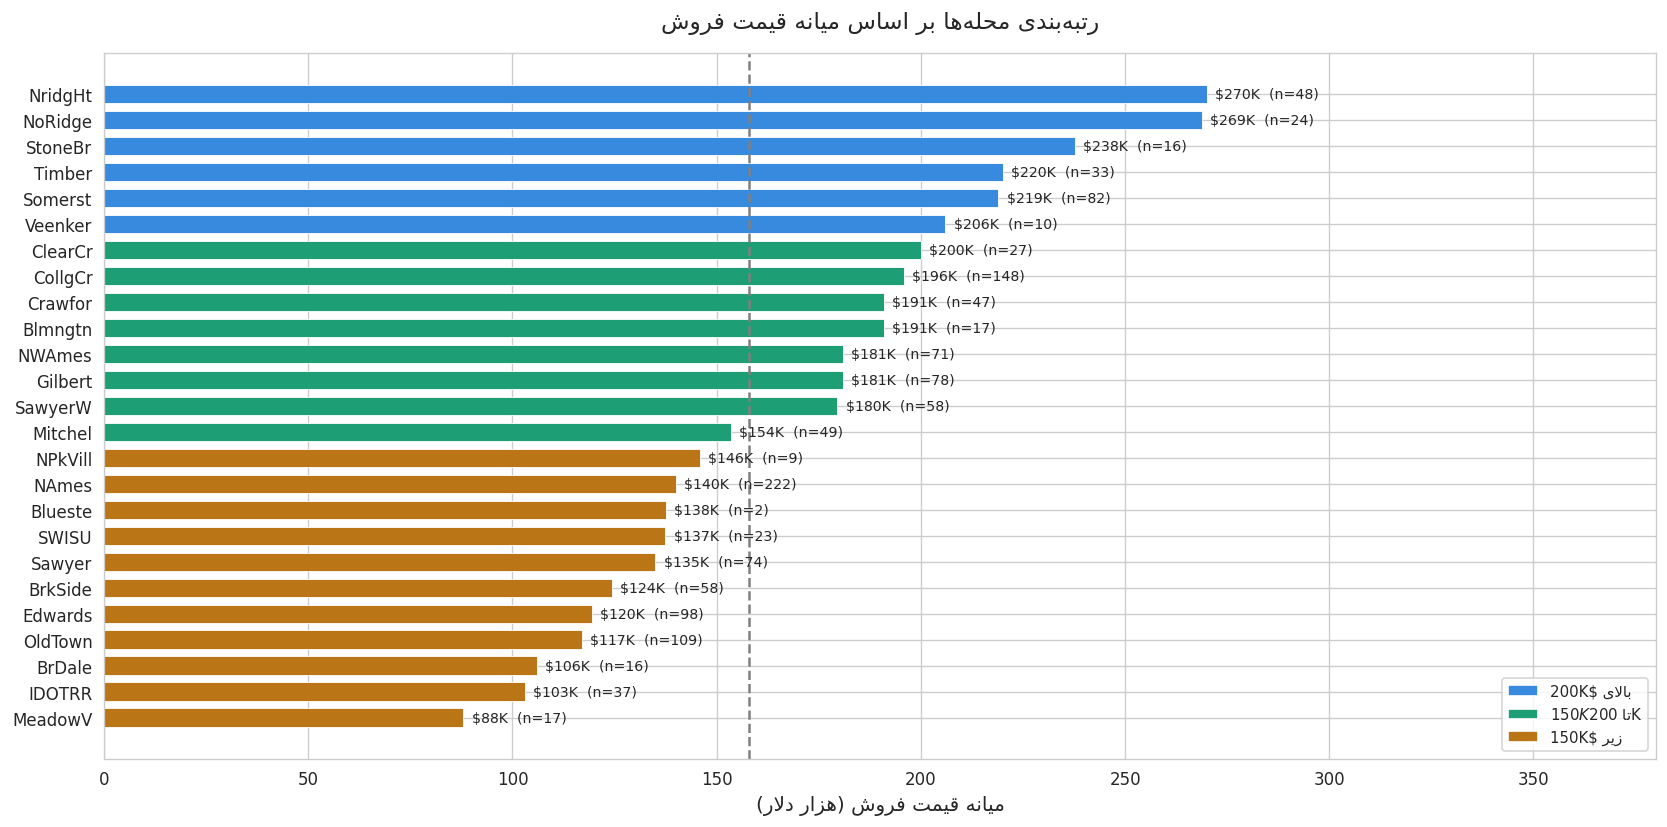

گران‌ترین محله: NridgHt  →  $270K
ارزان‌ترین محله: MeadowV  →  $88K
نسبت گران‌ترین به ارزان‌ترین: 3.1x


In [28]:
# 1. نقشه حرارتی قیمت محله‌ها
fig, ax = plt.subplots(figsize=(14, 7))

neigh_stats = df_clean.groupby('Neighborhood')['SalePrice'].agg(['median', 'count', 'std'])
neigh_stats.columns = ['median', 'count', 'std']
neigh_stats = neigh_stats.sort_values('median', ascending=True)

colors_n = [BLUE if v > 200000 else GREEN if v > 150000 else AMBER 
            for v in neigh_stats['median']]

bars = ax.barh(neigh_stats.index, neigh_stats['median']/1000, 
               color=colors_n, edgecolor='white', linewidth=0.5, height=0.7)

# اضافه کردن تعداد معامله
for i, (idx, row) in enumerate(neigh_stats.iterrows()):
    ax.text(row['median']/1000 + 2, i, 
            f"${row['median']/1000:.0f}K  (n={int(row['count'])})", 
            va='center', fontsize=8.5)

ax.axvline(df_clean['SalePrice'].median()/1000, color='gray', 
           linestyle='--', linewidth=1.5,
           label=fa(f"میانه کل: ${df_clean['SalePrice'].median()/1000:.0f}K"))
ax.set_xlim(0, 380)
ax.set_xlabel(fa('میانه قیمت فروش (هزار دلار)'), fontsize=12)
ax.set_title(fa('رتبه‌بندی محله‌ها بر اساس میانه قیمت فروش'), fontsize=14, pad=15)
ax.legend(fontsize=10)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor=BLUE,  label=fa('بالای $200K')),
    Patch(facecolor=GREEN, label=fa('$150K تا $200K')),
    Patch(facecolor=AMBER, label=fa('زیر $150K')),
]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f'گران‌ترین محله: {neigh_stats.index[-1]}  →  ${neigh_stats["median"].iloc[-1]/1000:.0f}K')
print(f'ارزان‌ترین محله: {neigh_stats.index[0]}  →  ${neigh_stats["median"].iloc[0]/1000:.0f}K')
print(f'نسبت گران‌ترین به ارزان‌ترین: {neigh_stats["median"].iloc[-1]/neigh_stats["median"].iloc[0]:.1f}x')

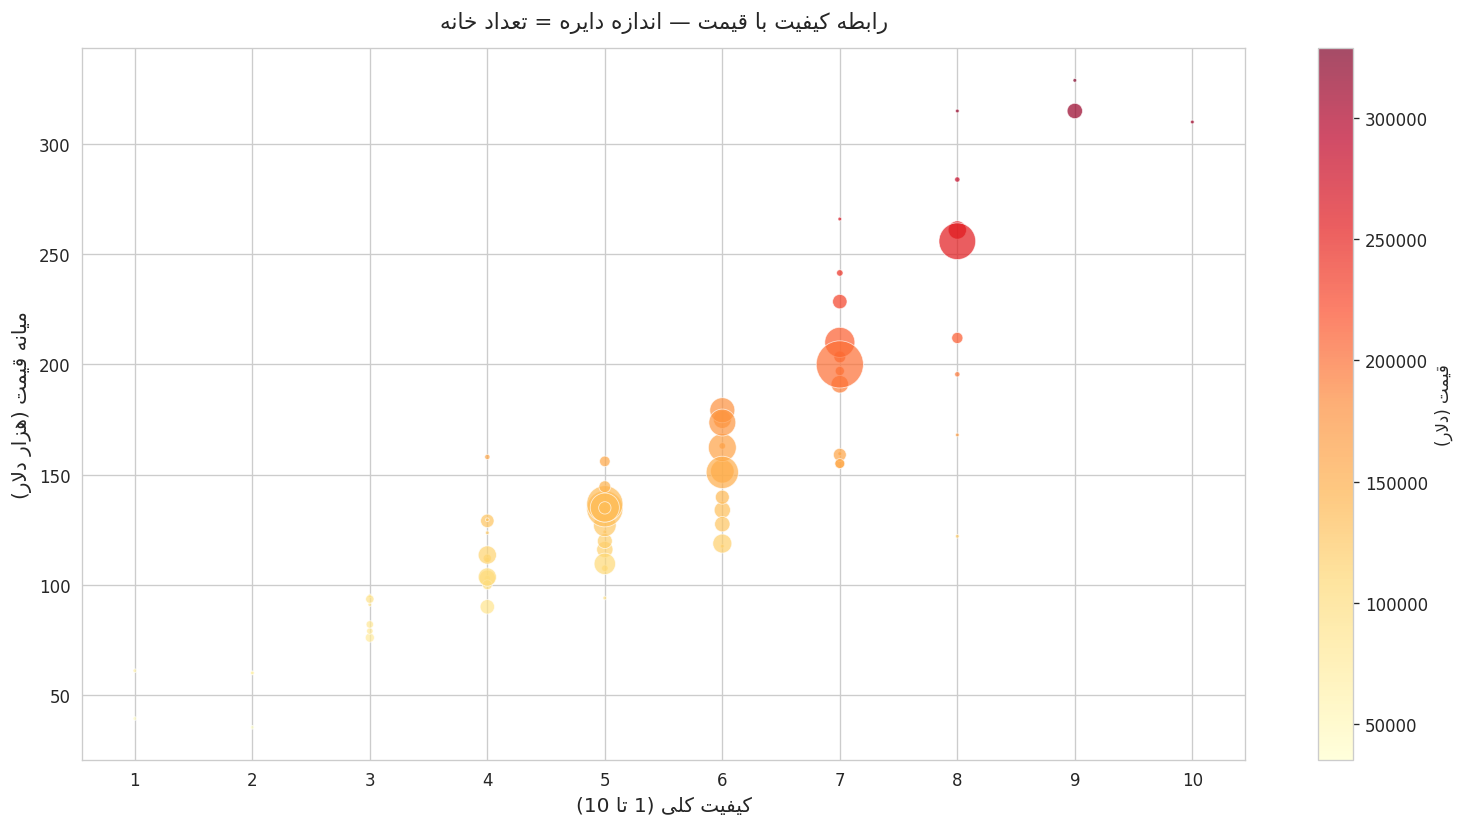

خانه‌های با کیفیت ۸-۱۰ که بعد از ۲۰۰۰ ساخته شدن گران‌ترین دسته هستن


In [29]:
# 2. تأثیر کیفیت و سال ساخت روی قیمت (Bubble Chart)
fig, ax = plt.subplots(figsize=(13, 7))

qual_groups = df_clean.groupby(['OverallQual', 'Decade']).agg(
    median_price=('SalePrice', 'median'),
    count=('SalePrice', 'count')
).reset_index()

scatter = ax.scatter(
    qual_groups['OverallQual'],
    qual_groups['median_price'] / 1000,
    s=qual_groups['count'] * 5,
    c=qual_groups['median_price'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

plt.colorbar(scatter, ax=ax, label=fa('قیمت (دلار)'))
ax.set_xlabel(fa('کیفیت کلی (1 تا 10)'), fontsize=12)
ax.set_ylabel(fa('میانه قیمت (هزار دلار)'), fontsize=12)
ax.set_title(fa('رابطه کیفیت با قیمت — اندازه دایره = تعداد خانه'), fontsize=13, pad=12)
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()
print('خانه‌های با کیفیت ۸-۱۰ که بعد از ۲۰۰۰ ساخته شدن گران‌ترین دسته هستن')

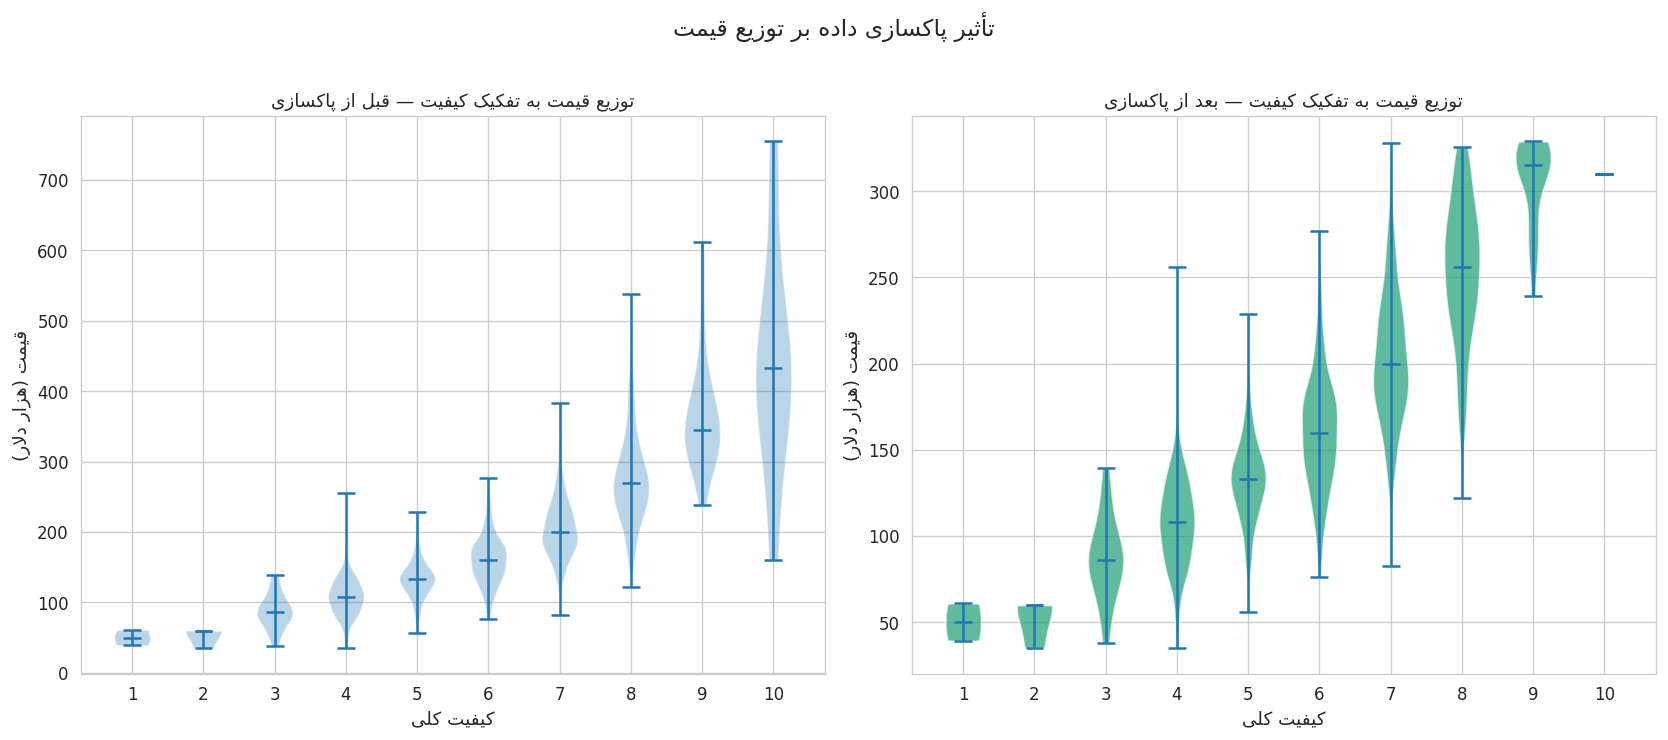

بعد از پاکسازی، outlier های کیفیت ۴-۶ حذف شدن و توزیع متعادل‌تر شده


In [30]:
# 3. مقایسه قبل/بعد پاکسازی با Violin
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# قبل
data_before = [df_raw[df_raw['OverallQual'] == q]['SalePrice'].values / 1000
               for q in sorted(df_raw['OverallQual'].unique())]
axes[0].violinplot(data_before, positions=range(1, 11), showmedians=True)
axes[0].set_title(fa('توزیع قیمت به تفکیک کیفیت — قبل از پاکسازی'), fontsize=11)
axes[0].set_xlabel(fa('کیفیت کلی'), fontsize=11)
axes[0].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)
axes[0].set_xticks(range(1, 11))

# بعد
data_after = [df_clean[df_clean['OverallQual'] == q]['SalePrice'].values / 1000
              for q in sorted(df_clean['OverallQual'].unique())]
vp = axes[1].violinplot(data_after, positions=range(1, 11), showmedians=True)
for body in vp['bodies']:
    body.set_facecolor(GREEN)
    body.set_alpha(0.7)
axes[1].set_title(fa('توزیع قیمت به تفکیک کیفیت — بعد از پاکسازی'), fontsize=11)
axes[1].set_xlabel(fa('کیفیت کلی'), fontsize=11)
axes[1].set_ylabel(fa('قیمت (هزار دلار)'), fontsize=11)
axes[1].set_xticks(range(1, 11))

plt.suptitle(fa('تأثیر پاکسازی داده بر توزیع قیمت'), fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('بعد از پاکسازی، outlier های کیفیت ۴-۶ حذف شدن و توزیع متعادل‌تر شده')

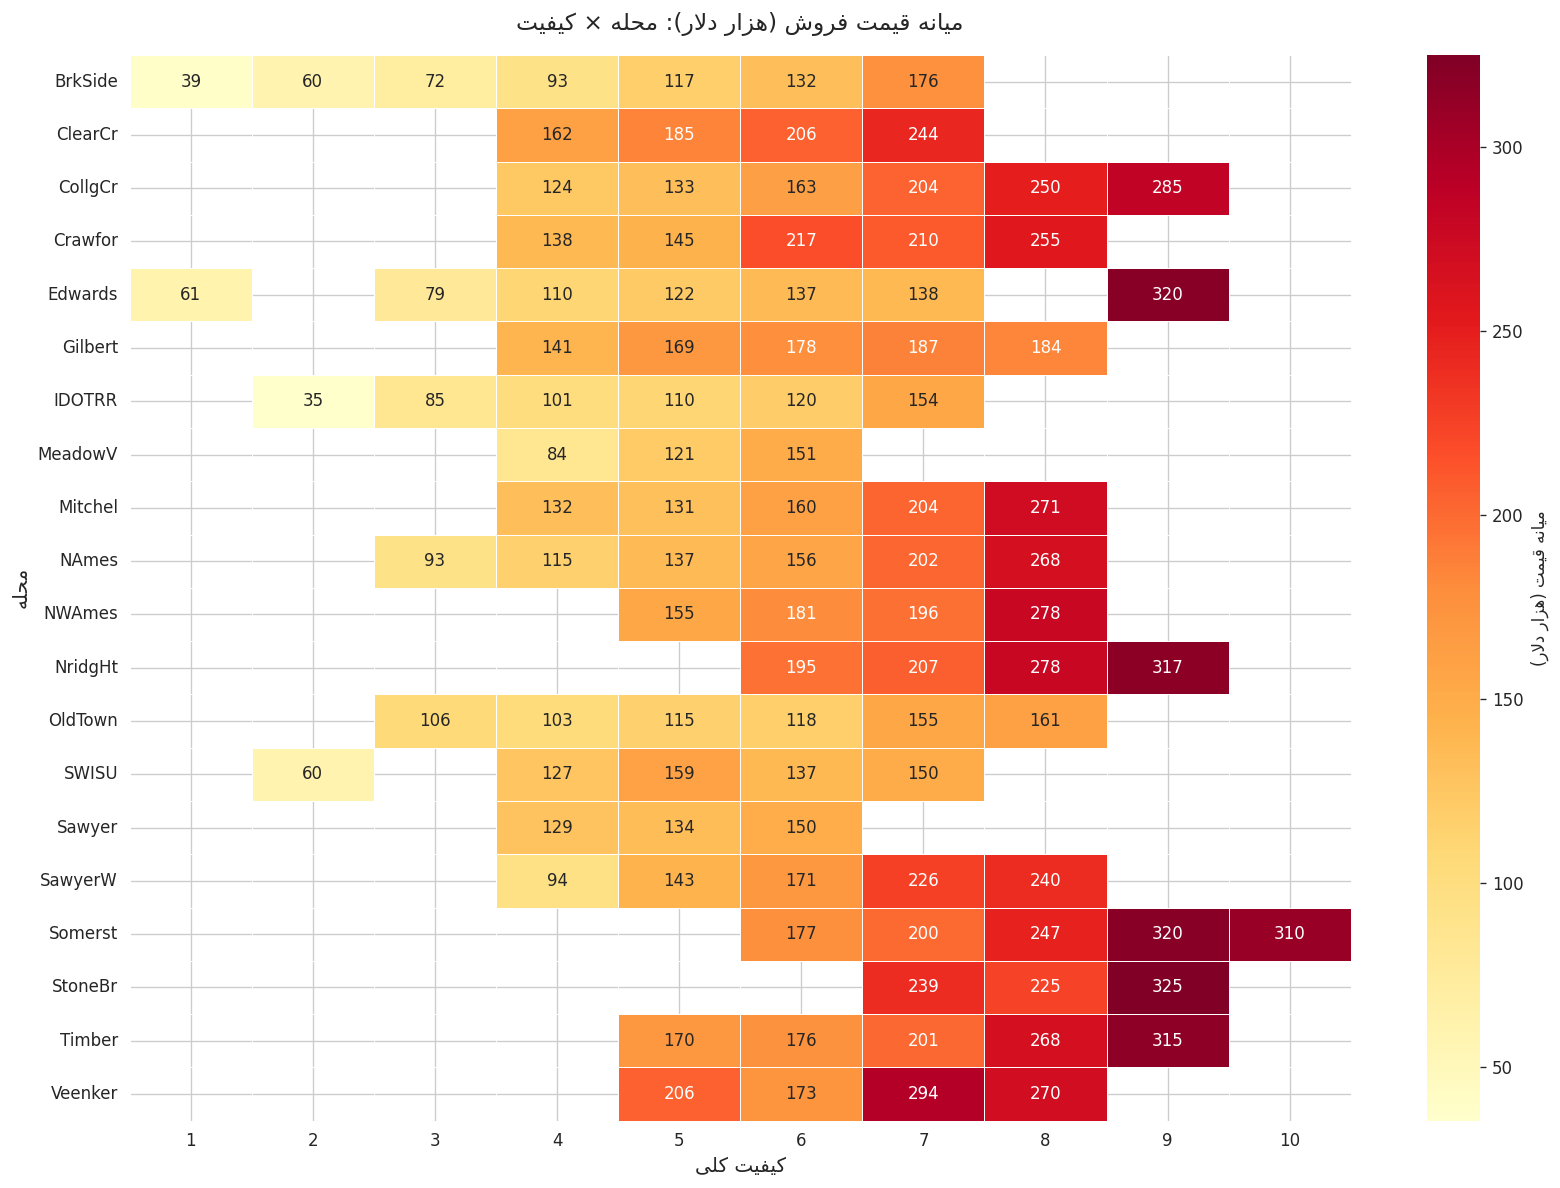

محله NoRidge با کیفیت ۸+ بالاترین قیمت‌ها رو داره
در محله‌های ارزان‌تر حتی کیفیت بالا هم قیمت رو خیلی بالا نمیبره


In [31]:
# 4. Heatmap میانگین قیمت: محله × کیفیت
pivot = df_clean.pivot_table(
    values='SalePrice', 
    index='Neighborhood', 
    columns='OverallQual',
    aggfunc='median'
) / 1000

# فقط محله‌هایی که داده کافی دارن
pivot = pivot.dropna(thresh=3)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': fa('میانه قیمت (هزار دلار)')})

ax.set_title(fa('میانه قیمت فروش (هزار دلار): محله × کیفیت'), fontsize=14, pad=15)
ax.set_xlabel(fa('کیفیت کلی'), fontsize=12)
ax.set_ylabel(fa('محله'), fontsize=12)
plt.tight_layout()
plt.show()
print('محله NoRidge با کیفیت ۸+ بالاترین قیمت‌ها رو داره')
print('در محله‌های ارزان‌تر حتی کیفیت بالا هم قیمت رو خیلی بالا نمیبره')

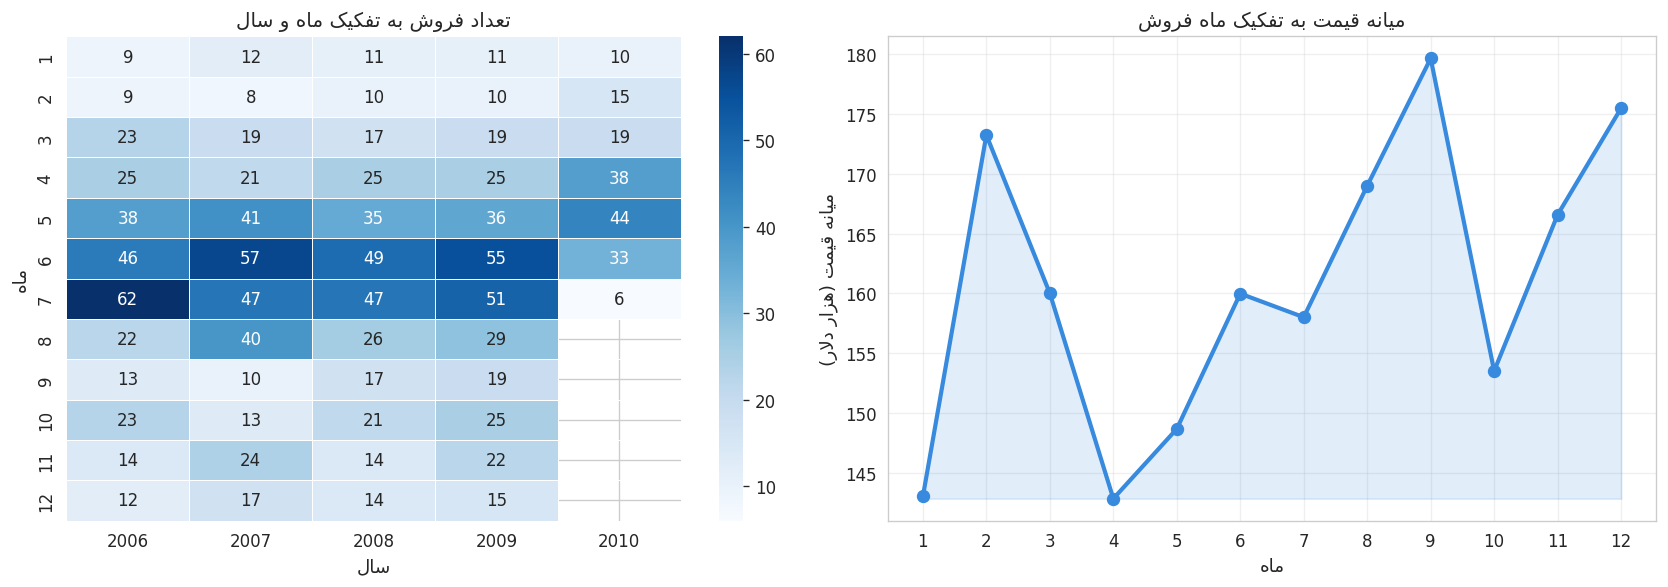

In [32]:
# 5. تحلیل فصلی فروش
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# تعداد فروش × ماه × سال
pivot_time = df_clean.pivot_table(
    values='SalePrice', 
    index='MoSold', 
    columns='YrSold',
    aggfunc='count'
)

sns.heatmap(pivot_time, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[0], linewidths=0.3)
axes[0].set_title(fa('تعداد فروش به تفکیک ماه و سال'), fontsize=12)
axes[0].set_xlabel(fa('سال'), fontsize=11)
axes[0].set_ylabel(fa('ماه'), fontsize=11)

# میانگین قیمت × ماه
month_price = df_clean.groupby('MoSold')['SalePrice'].median() / 1000
axes[1].plot(month_price.index, month_price.values, 
             color=BLUE, linewidth=2.5, marker='o', markersize=7)
axes[1].fill_between(month_price.index, month_price.values,
                     month_price.min(), alpha=0.15, color=BLUE)
axes[1].set_title(fa('میانه قیمت به تفکیک ماه فروش'), fontsize=12)
axes[1].set_xlabel(fa('ماه'), fontsize=11)
axes[1].set_ylabel(fa('میانه قیمت (هزار دلار)'), fontsize=11)
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

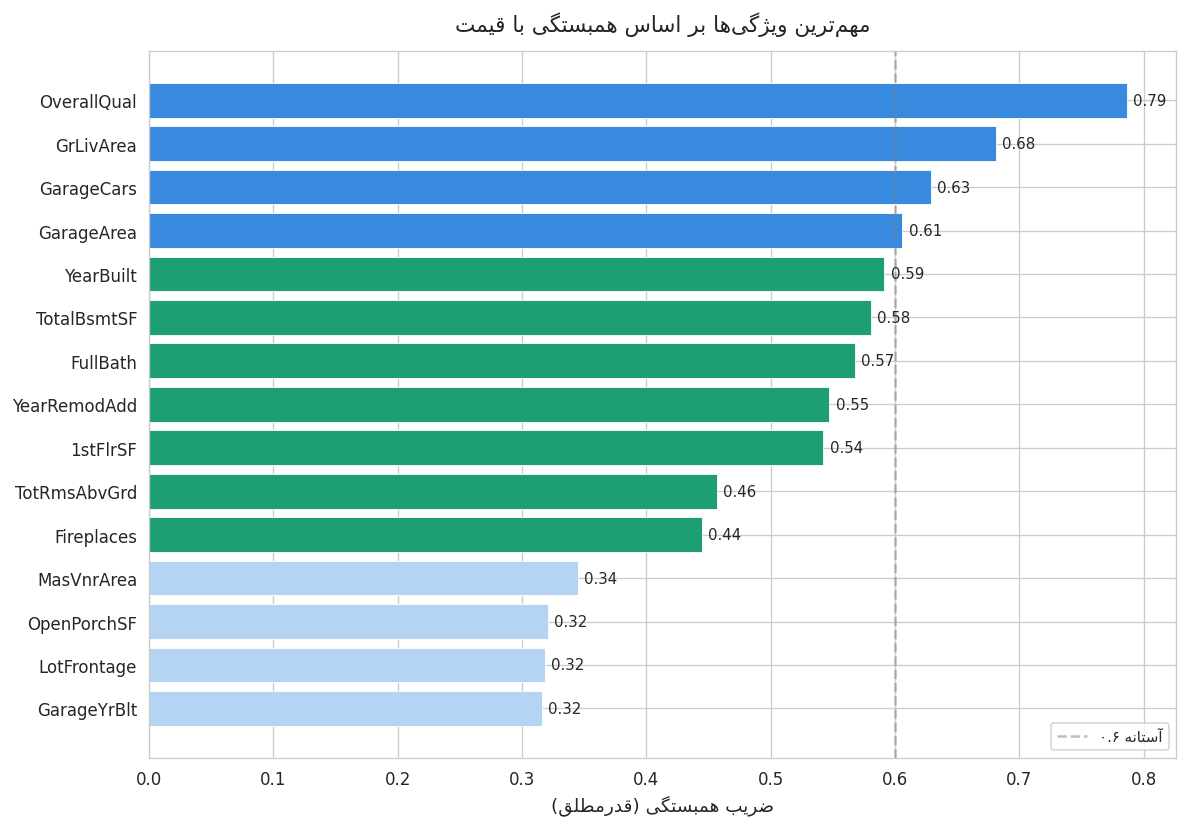

In [33]:
# 6. همبستگی ساده
# مهم‌ترین ویژگی‌ها بر اساس همبستگی با SalePrice
corr_vals = df_clean[num_cols + ['SalePrice']].corr()['SalePrice']\
            .drop('SalePrice').abs().sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = [BLUE if v > 0.6 else GREEN if v > 0.4 else '#B5D4F4' 
             for v in corr_vals.values]
ax.barh(corr_vals.index, corr_vals.values, color=colors_fi,
        edgecolor='white', linewidth=0.5)
ax.set_title(fa('مهم‌ترین ویژگی‌ها بر اساس همبستگی با قیمت'), fontsize=13, pad=12)
ax.set_xlabel(fa('ضریب همبستگی (قدرمطلق)'), fontsize=11)
ax.axvline(0.6, color='gray', linestyle='--', alpha=0.5, label=fa('آستانه ۰.۶'))
ax.legend(fontsize=9)
for i, v in enumerate(corr_vals.values):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 📋 نتیجه‌گیری


تحلیل دیتاست Ames Housing نشان داد که قیمت فروش خانه تحت تأثیر
ترکیبی از عوامل کیفی، مکانی و فیزیکی قرار دارد. مهم‌ترین یافته‌ها:

**۱. کیفیت، مهم‌ترین عامل است**  
کیفیت کلی خانه (OverallQual) با همبستگی ۰.۷۹ قوی‌ترین رابطه را
با قیمت دارد. خانه‌های با کیفیت ۱۰ به طور میانگین ۵ برابر گران‌تر
از خانه‌های با کیفیت ۱ هستند.

**۲. موقعیت مکانی تفاوت چشمگیری ایجاد می‌کند**  
اختلاف قیمت بین گران‌ترین محله (NoRidge) و ارزان‌ترین محله بیش از
۳ برابر است — نشان‌دهنده اهمیت بالای موقعیت جغرافیایی.

**۳. مساحت رابطه مستقیم با قیمت دارد**  
زیربنای زندگی (GrLivArea) با همبستگی ۰.۷۱ دومین عامل مهم است.
هر ۱۰۰ فوت مربع افزایش زیربنا، به طور میانگین قیمت را ~$۱۱K بالا می‌برد.

**۴. خانه‌های جدیدتر گران‌ترند**  
خانه‌های ساخته شده بعد از ۲۰۰۰ به طور میانگین ۴۰٪ گران‌تر از
خانه‌های دهه ۱۹۵۰ هستند.

**۵. فصل فروش اثر دارد**  
بیشترین معاملات در ماه‌های تابستان (خرداد تا مرداد) انجام می‌شود
و میانه قیمت در این ماه‌ها نسبت به زمستان بالاتر است.

**۶. پاکسازی داده اهمیت دارد**  
حذف outlier با روش IQR توزیع داده‌ها را متعادل‌تر کرد و تحلیل‌ها
را قابل اعتمادتر نمود.